# Modelos SARIMAX · Construcción por fases

## CONFIGURACIÓN · Librerías

In [ ]:
# =====================================================================
# CONFIGURACIÓN · LIBRERÍAS
# =====================================================================
# Todas las librerías e imports del notebook se centralizan AQUÍ.
# Instala dependencias no incluidas por defecto (entorno Colab)
!pip install -q xlsxwriter

# Manejo de datos
import pandas as pd
import numpy as np
import itertools
import json
import openpyxl

# Visualización
import matplotlib.pyplot as plt

# Series de tiempo / modelos / pruebas estadísticas
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

# Utilidades
import warnings
warnings.filterwarnings("ignore")

# Estilo general de las gráficas
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Librerías cargadas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.7 MB/s eta 0:00:00
Librerías cargadas correctamente.


## IDENTIFICACIÓN EXÓGENAS Y VISUALIZACIÓN DE VARIABLES

En esta sección se leen los **cuatro archivos base**, se identifica de forma
automática la variable endógena y las `n` exógenas, se valida la consistencia
de los escenarios y se visualizan las variables.

**Entradas (4 archivos `.xlsx`):**

| Archivo | Estructura |
|---|---|
| `ENDOGENA` | `fecha · endógena · exóg_1 · exóg_2 · … · exóg_n` (histórico) |
| `EXO_BAS`  | `fecha · exóg_1_BAS · … · exóg_n_BAS` (proyección **base**) |
| `EXO_ADV`  | `fecha · exóg_1_ADV · … · exóg_n_ADV` (proyección **adversa**) |
| `EXO_OPT`  | `fecha · exóg_1_OPT · … · exóg_n_OPT` (proyección **optimista**) |

- La **fecha** sigue un patrón (mensual / trimestral / anual) que se detecta y se
  reporta como `ORDEN TEMPORAL`.
- Los archivos de escenarios son la **continuación inmediata** del histórico de la
  endógena y mantienen el **mismo orden** de las exógenas, distinguidas por su sufijo.

**Salida de trazabilidad:**
- `var_endogena_orig` → vector único con la endógena.
- `var_exogenas_orig` → vector dinámico con las exógenas.

El flujo se reparte en 4 celdas: **(1)** cargue de archivos, **(2)** automatización /
extracción y validación, **(3)** reporte y gráficas, **(4)** definición explícita de
las variables.


In [ ]:
# =====================================================================
# CELDA 1 · CARGUE DE LOS ARCHIVOS
# ---------------------------------------------------------------------
# El usuario sube a la sesión de Colab los CUATRO archivos base y SOLO
# modifica los nombres aquí abajo. La extensión esperada es .xlsx
# (también se aceptan .csv de ejemplo para pruebas locales).
# =====================================================================

# --- NOMBRES DE LOS ARCHIVOS (EDITAR SEGÚN CORRESPONDA) --------------
ARCHIVO_ENDOGENA = "hist_vivi_co_fwl_pd12.xlsx"
ARCHIVO_EXO_BAS  = "bas_macro_davi_vivi_co_fwl_pd12.xlsx"
ARCHIVO_EXO_ADV  = "adv_macro_davi__vivi_co_fwl_pd12.xlsx"
ARCHIVO_EXO_OPT  = "opt_macro_davi__vivi_co_fwl_pd12.xlsx"

# --- Sufijos que distinguen cada escenario (no editar) --------------
SUFIJOS_ESCENARIO = {"BAS": "_BAS", "ADV": "_ADV", "OPT": "_OPT"}


def leer_archivo(ruta):
    """Lee un .xlsx (o .csv de ejemplo) y limpia columnas/filas vacías."""
    if str(ruta).lower().endswith(".csv"):
        df = pd.read_csv(ruta)
    else:
        df = pd.read_excel(ruta)
    # Quita columnas auxiliares vacías ('Unnamed: x') y filas/columnas 100% NaN
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    return df


# Lectura cruda de los cuatro archivos
df_endogena_raw = leer_archivo(ARCHIVO_ENDOGENA)
df_exo_bas_raw  = leer_archivo(ARCHIVO_EXO_BAS)
df_exo_adv_raw  = leer_archivo(ARCHIVO_EXO_ADV)
df_exo_opt_raw  = leer_archivo(ARCHIVO_EXO_OPT)

print("Archivos cargados correctamente:")
for nombre, df in [("ENDOGENA", df_endogena_raw), ("EXO_BAS", df_exo_bas_raw),
                   ("EXO_ADV", df_exo_adv_raw), ("EXO_OPT", df_exo_opt_raw)]:
    print(f"   - {nombre:9s}: {df.shape[0]:>4} filas x {df.shape[1]} columnas  ->  {list(df.columns)}")

# --- Recuperar metadata del Generador (si el archivo la trae embebida) ---
def _leer_meta_generador(ruta_archivo, prefix="sarimax_meta_generador"):
    try:
        wb = openpyxl.load_workbook(ruta_archivo, read_only=True)
        props = wb.custom_doc_props
        if f"{prefix}_n" not in props.names:
            return {}
        n = int(props[f"{prefix}_n"].value)
        partes = [props[f"{prefix}_{i:02d}"].value for i in range(1, n + 1)]
        return json.loads("".join(partes))
    except Exception:
        return {}

META_GENERADOR = _leer_meta_generador(ARCHIVO_ENDOGENA)
if META_GENERADOR:
    print("\nMetadata del Generador recuperada:", META_GENERADOR)
else:
    print("\nEste archivo no trae metadata del Generador (define PAIS_MOTOR/CARTERA_MOTOR manualmente más abajo).")

Archivos cargados correctamente:
   - ENDOGENA :   78 filas x 11 columnas  ->  ['fecha', 'ENDÓGENA', 'VAR_MENSUAL_PIB', 'VAR_MENSUAL_IPC', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO', 'VAR_TRIMESTRAL_PIB', 'VAR_TRIMESTRAL_IPC', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO', 'VAR_ANUAL_PIB', 'VAR_ANUAL_IPC', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO']
   - EXO_BAS  :   45 filas x 10 columnas  ->  ['fecha', 'VAR_MENSUAL_PIB_BAS', 'VAR_MENSUAL_IPC_BAS', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO_BAS', 'VAR_TRIMESTRAL_PIB_BAS', 'VAR_TRIMESTRAL_IPC_BAS', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO_BAS', 'VAR_ANUAL_PIB_BAS', 'VAR_ANUAL_IPC_BAS', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO_BAS']
   - EXO_ADV  :   45 filas x 10 columnas  ->  ['fecha', 'VAR_MENSUAL_PIB_ADV', 'VAR_MENSUAL_IPC_ADV', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO_ADV', 'VAR_TRIMESTRAL_PIB_ADV', 'VAR_TRIMESTRAL_IPC_ADV', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO_ADV', 'VAR_ANUAL_PIB_ADV', 'VAR_ANUAL_IPC_ADV', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO_ADV']
   - EXO_OPT  :   45 filas x 10 columnas  ->  ['f

In [ ]:
# =====================================================================
# CELDA 2 · AUTOMATIZACIÓN, EXTRACCIÓN Y LECTURA DE LAS VARIABLES
# ---------------------------------------------------------------------
# Se identifican automáticamente:
#   - la columna de fecha y su ORDEN TEMPORAL (mensual/trimestral/anual)
#   - el nombre de la ENDÓGENA  (2a columna del archivo ENDOGENA)
#   - el nombre y el número (n) de las EXÓGENAS (3a columna en adelante)
# y se valida la consistencia de los tres escenarios (BAS/ADV/OPT).
# =====================================================================

def detectar_orden_temporal(indice_fechas):
    """Devuelve (etiqueta, alias_pandas, paso) según el espaciado de las fechas."""
    dias = indice_fechas.to_series().diff().dropna().dt.days.median()
    if dias <= 45:
        return "MENSUAL", "MS", pd.DateOffset(months=1)
    elif dias <= 135:
        return "TRIMESTRAL", "QS", pd.DateOffset(months=3)
    else:
        return "ANUAL", "YS", pd.DateOffset(years=1)


def preparar_fecha(df):
    """Toma la 1a columna como fecha, la convierte a datetime y la usa de índice."""
    df = df.copy()
    col_fecha = df.columns[0]
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    df = df.dropna(subset=[col_fecha]).sort_values(col_fecha).set_index(col_fecha)
    df.index.name = "Fecha"
    return df


# ---- 1) ENDÓGENA: fecha + endógena + n exógenas (histórico) ---------
df_endo = preparar_fecha(df_endogena_raw)

nombre_endogena  = df_endo.columns[0]          # 2a columna del archivo original
nombres_exogenas = list(df_endo.columns[1:])   # 3a columna en adelante (en orden)
n_exogenas       = len(nombres_exogenas)

orden_temporal, freq_alias, paso_temporal = detectar_orden_temporal(df_endo.index)

# Variables ORIGEN (histórico)
var_endogena_orig = df_endo[nombre_endogena].astype(float)     # vector único endógena
var_exogenas_orig = df_endo[nombres_exogenas].astype(float)    # vector dinámico exógenas

fecha_ini_endo = df_endo.index.min()
fecha_fin_endo = df_endo.index.max()

# ---- 2) ESCENARIOS EXÓGENOS (BAS / ADV / OPT) ----------------------
escenarios = {}           # {'BAS': df, 'ADV': df, 'OPT': df}  columnas = nombres_exogenas
reporte_validacion = []   # mensajes que se imprimen en la CELDA 3

raw_por_escenario = {"BAS": df_exo_bas_raw, "ADV": df_exo_adv_raw, "OPT": df_exo_opt_raw}

for esc, df_raw in raw_por_escenario.items():
    suf = SUFIJOS_ESCENARIO[esc]
    df_esc = preparar_fecha(df_raw)

    # Quita el sufijo (_BAS/_ADV/_OPT) para alinear con las exógenas originales
    columnas_sin_suf = [c[:-len(suf)] if str(c).endswith(suf) else c for c in df_esc.columns]
    df_esc.columns = columnas_sin_suf

    # Validación de nombres y orden vs. ENDÓGENA
    if columnas_sin_suf == nombres_exogenas:
        reporte_validacion.append(f"   [OK] {esc}: nombres y orden de exógenas coinciden (sufijo {suf}).")
    else:
        reporte_validacion.append(
            f"   [!!] {esc}: las exógenas NO coinciden con la endógena.\n"
            f"        Esperado: {nombres_exogenas}\n"
            f"        Hallado : {columnas_sin_suf}")

    # Validación de continuidad temporal inmediata
    fecha_esperada = fecha_fin_endo + paso_temporal
    fecha_ini_esc = df_esc.index.min()
    if fecha_ini_esc == fecha_esperada:
        reporte_validacion.append(f"   [OK] {esc}: inicia en {fecha_ini_esc:%d/%m/%Y} (continuación inmediata).")
    else:
        reporte_validacion.append(
            f"   [!!] {esc}: inicia en {fecha_ini_esc:%d/%m/%Y} pero se esperaba {fecha_esperada:%d/%m/%Y}.")

    # Se conservan sólo las exógenas válidas, en el orden de la endógena
    cols_validas = [c for c in nombres_exogenas if c in df_esc.columns]
    escenarios[esc] = df_esc[cols_validas].astype(float)

# Rango de proyección (referencia: escenario base)
fecha_ini_proy = escenarios["BAS"].index.min()
fecha_fin_proy = escenarios["BAS"].index.max()

print("Extracción y validación completadas. (Reporte detallado en la CELDA 3.)")


Extracción y validación completadas. (Reporte detallado en la CELDA 3.)


        IDENTIFICACIÓN DE VARIABLES · REPORTE GENERAL
ORDEN TEMPORAL          : MENSUAL
VARIABLE ENDÓGENA       : ENDÓGENA
N° EXÓGENAS             : 9
VARIABLES EXÓGENAS      : VAR_MENSUAL_PIB, VAR_MENSUAL_IPC, VAR_MENSUAL_PROM_TRIM_DESEMPLEO, VAR_TRIMESTRAL_PIB, VAR_TRIMESTRAL_IPC, VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO, VAR_ANUAL_PIB, VAR_ANUAL_IPC, VAR_ANUAL_PROM_TRIM_DESEMPLEO
------------------------------------------------------------------------
HISTÓRICO  (endógena)   : 01/10/2018  ->  01/03/2025   (78 obs.)
PROYECCIÓN (escenarios) : 01/04/2025  ->  01/12/2028   (45 obs.)
------------------------------------------------------------------------
VALIDACIÓN DE ESCENARIOS:
   [OK] BAS: nombres y orden de exógenas coinciden (sufijo _BAS).
   [OK] BAS: inicia en 01/04/2025 (continuación inmediata).
   [OK] ADV: nombres y orden de exógenas coinciden (sufijo _ADV).
   [OK] ADV: inicia en 01/04/2025 (continuación inmediata).
   [OK] OPT: nombres y orden de exógenas coinciden (sufijo _OPT).


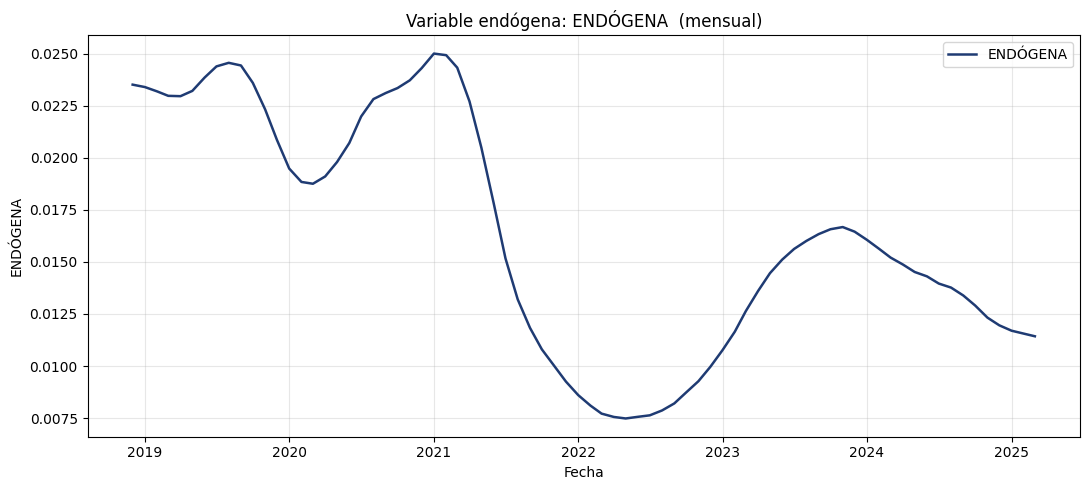

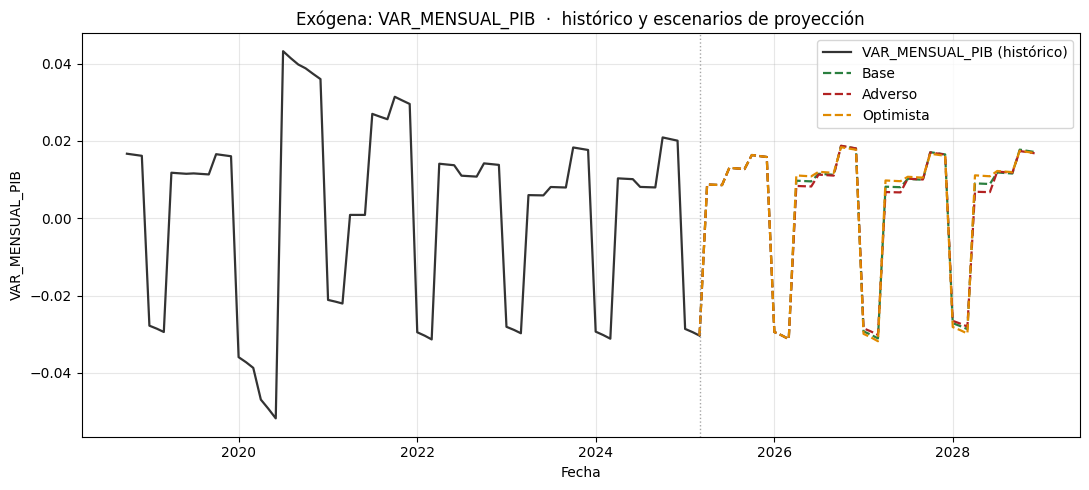

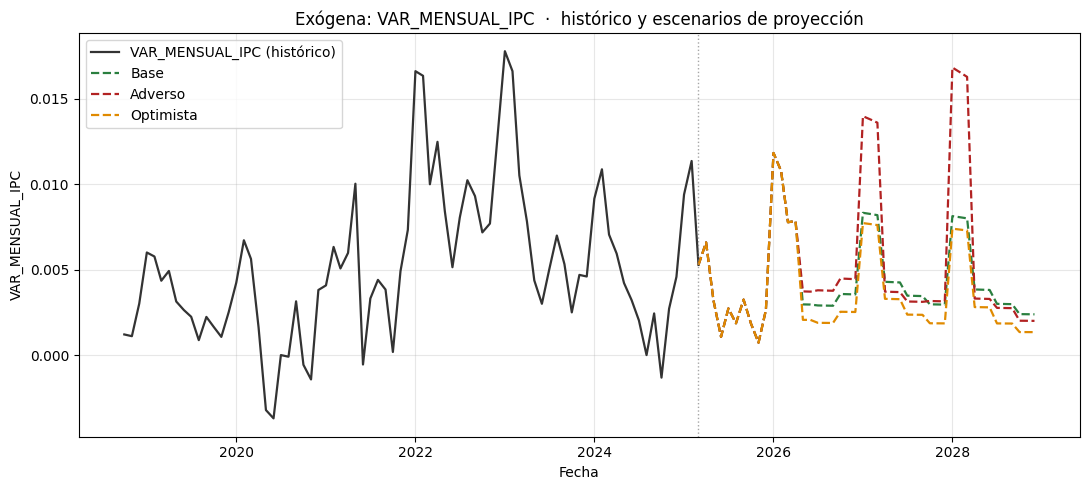

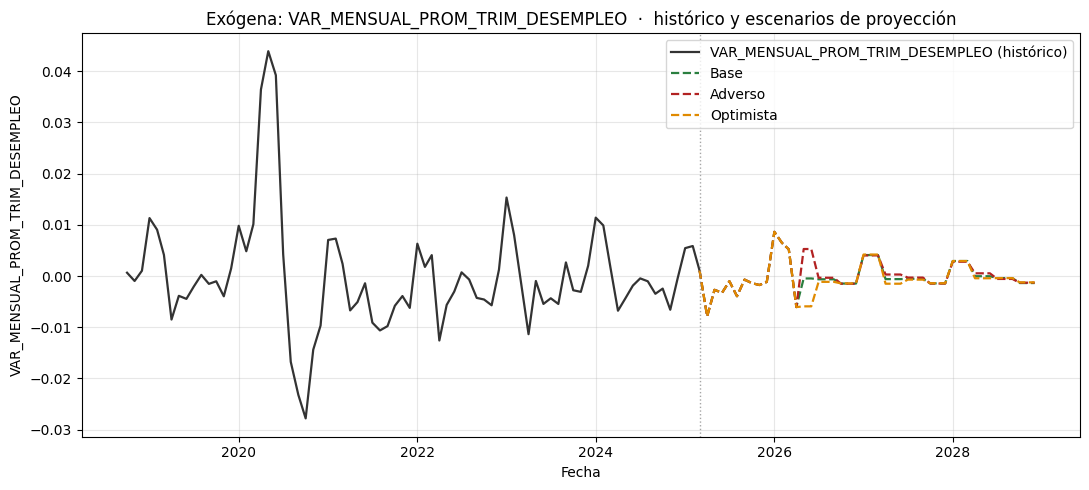

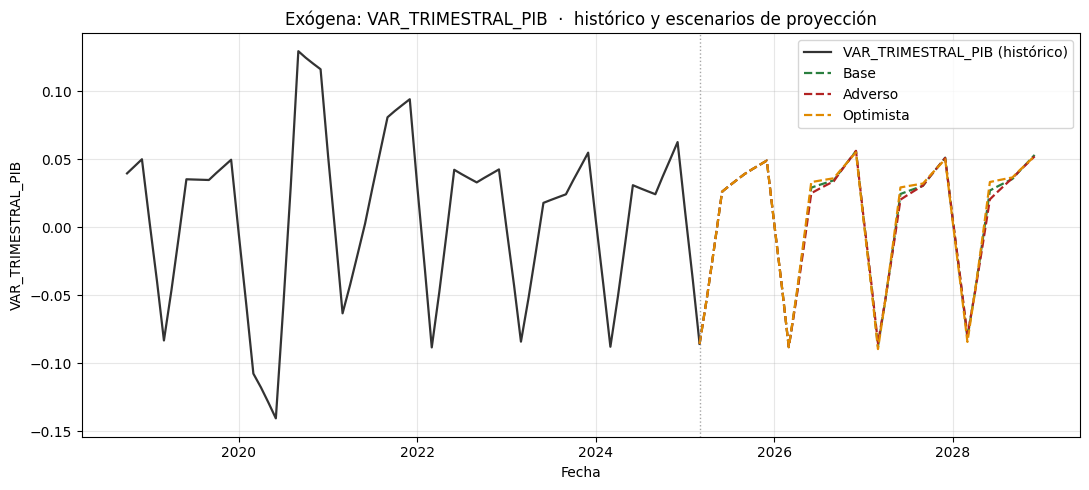

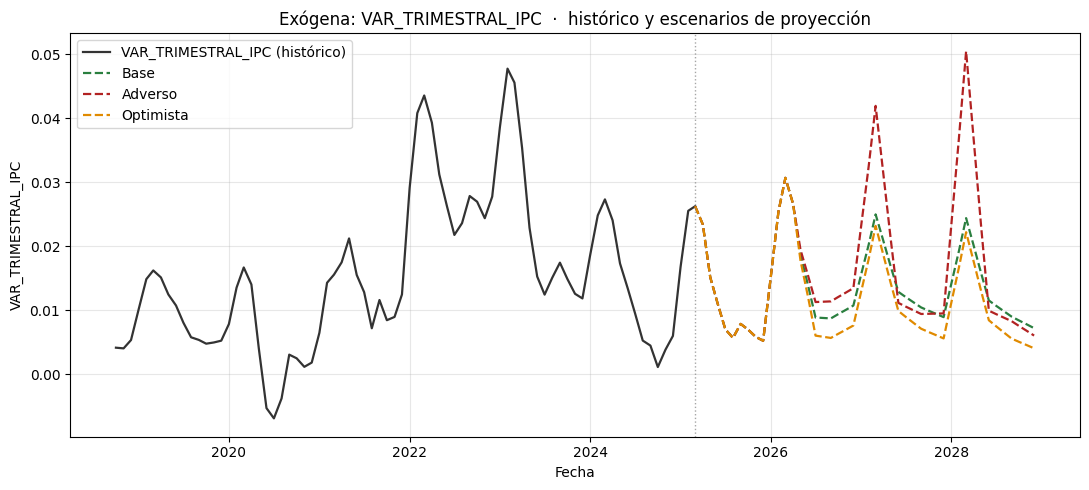

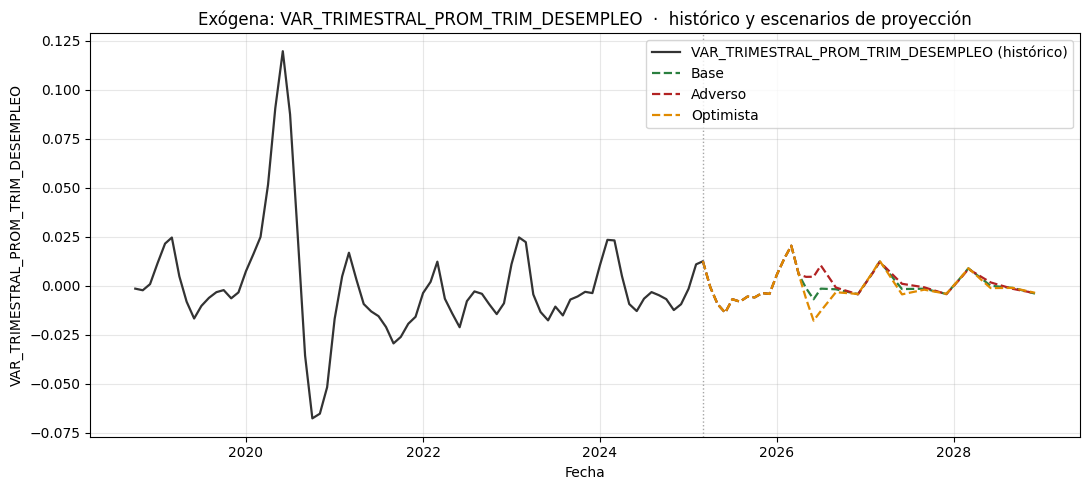

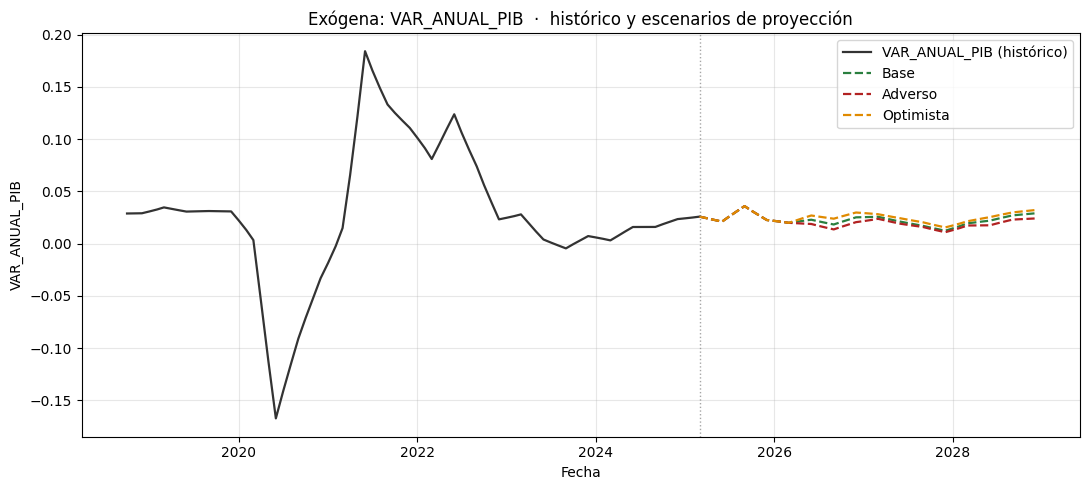

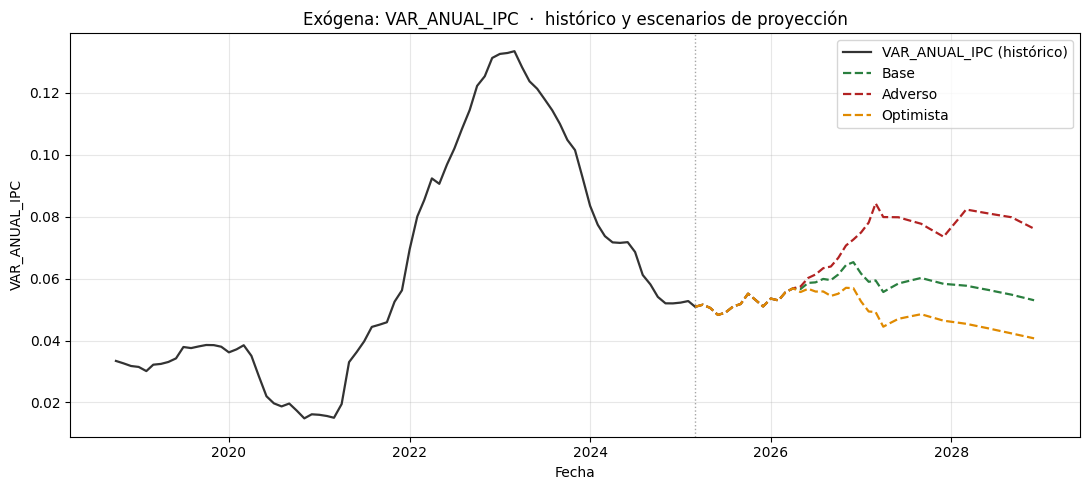

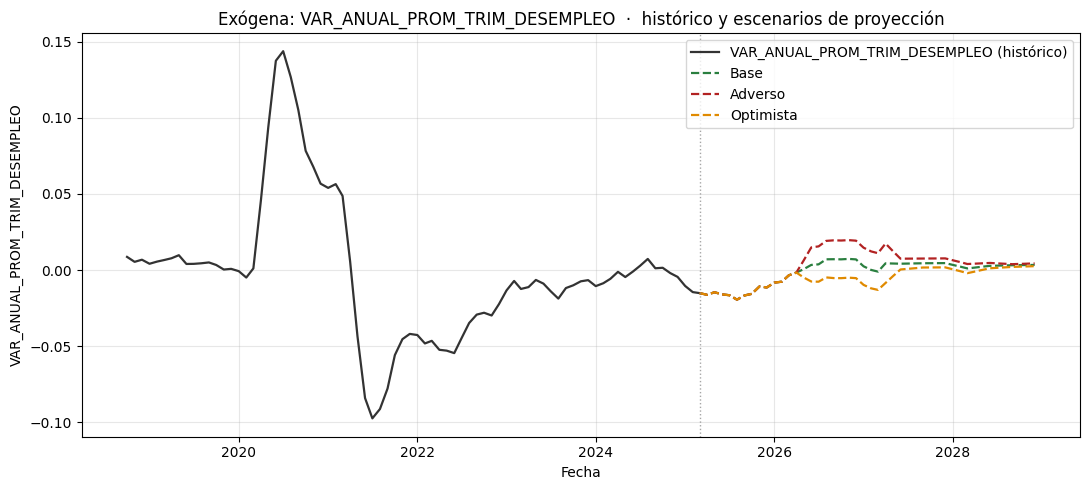

In [ ]:
# =====================================================================
# CELDA 3 · REPORTE Y VISUALIZACIÓN DE VARIABLES
# =====================================================================

# ------------------------- REPORTE GENERAL ---------------------------
print("=" * 72)
print("        IDENTIFICACIÓN DE VARIABLES · REPORTE GENERAL")
print("=" * 72)
print(f"ORDEN TEMPORAL          : {orden_temporal}")
print(f"VARIABLE ENDÓGENA       : {nombre_endogena}")
print(f"N° EXÓGENAS             : {n_exogenas}")
print(f"VARIABLES EXÓGENAS      : {', '.join(nombres_exogenas)}")
print("-" * 72)
print(f"HISTÓRICO  (endógena)   : {fecha_ini_endo:%d/%m/%Y}  ->  {fecha_fin_endo:%d/%m/%Y}   ({len(df_endo)} obs.)")
print(f"PROYECCIÓN (escenarios) : {fecha_ini_proy:%d/%m/%Y}  ->  {fecha_fin_proy:%d/%m/%Y}   ({len(escenarios['BAS'])} obs.)")
print("-" * 72)
print("VALIDACIÓN DE ESCENARIOS:")
for linea in reporte_validacion:
    print(linea)
print("=" * 72)

# --------------------- REPORTE POR CADA EXÓGENA ----------------------
for i, exo in enumerate(nombres_exogenas, start=1):
    print(f"\n>>> EXÓGENA {i}/{n_exogenas}: {exo}")
    hist = var_exogenas_orig[exo]
    print(f"    Histórico    : media={hist.mean():.4f} | min={hist.min():.4f} | max={hist.max():.4f}")
    for esc in ["BAS", "ADV", "OPT"]:
        s = escenarios[esc][exo]
        print(f"    Escenario {esc}: media={s.mean():.4f} | min={s.min():.4f} | max={s.max():.4f}")

# ------------------------- GRÁFICA ENDÓGENA --------------------------
fig, ax = plt.subplots()
ax.plot(var_endogena_orig.index, var_endogena_orig.values,
        color="#1f3b73", lw=1.8, label=nombre_endogena)
ax.set_title(f"Variable endógena: {nombre_endogena}  ({orden_temporal.lower()})")
ax.set_xlabel("Fecha")
ax.set_ylabel(nombre_endogena)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ----------- GRÁFICA POR EXÓGENA (histórico + 3 escenarios) ----------
colores   = {"BAS": "#2a7f3f", "ADV": "#b22222", "OPT": "#e08a00"}
etiquetas = {"BAS": "Base", "ADV": "Adverso", "OPT": "Optimista"}

for exo in nombres_exogenas:
    fig, ax = plt.subplots()
    hist = var_exogenas_orig[exo]
    ax.plot(hist.index, hist.values, color="#333333", lw=1.6, label=f"{exo} (histórico)")

    # Se enlaza el último punto del histórico para dar continuidad visual
    ultimo_x, ultimo_y = hist.index[-1], hist.values[-1]
    for esc in ["BAS", "ADV", "OPT"]:
        s = escenarios[esc][exo]
        x = [ultimo_x] + list(s.index)
        y = [ultimo_y] + list(s.values)
        ax.plot(x, y, color=colores[esc], lw=1.6, ls="--", label=etiquetas[esc])

    ax.axvline(ultimo_x, color="grey", ls=":", lw=1, alpha=0.7)
    ax.set_title(f"Exógena: {exo}  ·  histórico y escenarios de proyección")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(exo)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


In [ ]:
# =====================================================================
# CELDA 4 · DEFINICIÓN EXPLÍCITA DE LAS VARIABLES (TRAZABILIDAD)
# ---------------------------------------------------------------------
# Variables ORIGEN que los bloques siguientes llamarán y/o transformarán.
# Aquí NO se transforman: sólo se dejan declaradas con su nombre final.
#
#   var_endogena_orig -> Series   (vector único con la endógena, histórico)
#   var_exogenas_orig -> DataFrame (vector dinámico con las exógenas, histórico)
# =====================================================================

print("VARIABLES DEFINIDAS PARA LOS SIGUIENTES BLOQUES")
print("-" * 60)
print(f"var_endogena_orig  -> Series    '{nombre_endogena}'  ({len(var_endogena_orig)} obs.)")
print(f"var_exogenas_orig  -> DataFrame {list(var_exogenas_orig.columns)}  ({var_exogenas_orig.shape[0]} obs.)")
print()
print("Metadatos de trazabilidad disponibles:")
print(f"   orden_temporal   = '{orden_temporal}'   (freq pandas: '{freq_alias}')")
print(f"   nombre_endogena  = '{nombre_endogena}'")
print(f"   nombres_exogenas = {nombres_exogenas}")
print(f"   n_exogenas       = {n_exogenas}")
print(f"   escenarios       = dict con claves {list(escenarios.keys())} (proyección de exógenas)")
print()
print("Vista previa de var_exogenas_orig (últimas filas del histórico):")
display(var_exogenas_orig.tail())


VARIABLES DEFINIDAS PARA LOS SIGUIENTES BLOQUES
------------------------------------------------------------
var_endogena_orig  -> Series    'ENDÓGENA'  (78 obs.)
var_exogenas_orig  -> DataFrame ['VAR_MENSUAL_PIB', 'VAR_MENSUAL_IPC', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO', 'VAR_TRIMESTRAL_PIB', 'VAR_TRIMESTRAL_IPC', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO', 'VAR_ANUAL_PIB', 'VAR_ANUAL_IPC', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO']  (78 obs.)

Metadatos de trazabilidad disponibles:
   orden_temporal   = 'MENSUAL'   (freq pandas: 'MS')
   nombre_endogena  = 'ENDÓGENA'
   nombres_exogenas = ['VAR_MENSUAL_PIB', 'VAR_MENSUAL_IPC', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO', 'VAR_TRIMESTRAL_PIB', 'VAR_TRIMESTRAL_IPC', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO', 'VAR_ANUAL_PIB', 'VAR_ANUAL_IPC', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO']
   n_exogenas       = 9
   escenarios       = dict con claves ['BAS', 'ADV', 'OPT'] (proyección de exógenas)

Vista previa de var_exogenas_orig (últimas filas del histórico):


,VAR_MENSUAL_PIB,VAR_MENSUAL_IPC,VAR_MENSUAL_PROM_TRIM_DESEMPLEO,VAR_TRIMESTRAL_PIB,VAR_TRIMESTRAL_IPC,VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO,VAR_ANUAL_PIB,VAR_ANUAL_IPC,VAR_ANUAL_PROM_TRIM_DESEMPLEO
Fecha,,,,,,,,,
2024-11-01,0.020477,0.002712,-0.006583,0.050119,0.003828,-0.012503,0.021148,0.052010,-0.001965
2024-12-01,0.020066,0.004576,-0.000489,0.062714,0.005971,-0.009525,0.023561,0.051990,-0.004465
2025-01-01,-0.028612,0.009387,0.005452,0.011170,0.016756,-0.001620,0.024303,0.052238,-0.010425
2025-02-01,-0.029454,0.011351,0.005864,-0.038306,0.025517,0.010827,0.025091,0.052744,-0.014449
2025-03-01,-0.030348,0.005274,0.001058,-0.085835,0.026229,0.012374,0.025930,0.050891,-0.015117


## MOTOR DE MODELOS DE SARIMAX
Configuración de Parametros para los bloques

In [90]:
# =====================================================================
# MOTOR DE MODELOS SARIMAX · CONFIGURACIÓN DE PARÁMETROS POR BLOQUE
# ---------------------------------------------------------------------
# Punto ÚNICO para editar los parámetros de todos los bloques. Edita aquí
# los valores y luego corre los bloques en orden. Las funciones y librerías
# están en la sección CONFIGURACIÓN · LIBRERÍAS.
# =====================================================================

# ---------------------------------------------------------------------
# BLOQUE 1 (EXÓGENAS · estacionariedad)
#   Encuentra la d mínima para volver estacionarias las exógenas.
#   Sin participación del usuario -> ver resultados en la celda B1.3.
# ---------------------------------------------------------------------
# (sin parámetros editables)

# ---------------------------------------------------------------------
# BLOQUE 2 (ENDÓGENA · tipo y diferenciación)
#   Los primeros CUATRO parámetros configuran la prueba ADF que evalúa si
#   la endógena (original y logit) es estacionaria con d <= umbral (B2.1/B2.2).
#   Los otros TRES (B2.3) definen el tipo de endógena final y los órdenes p, q.
#   IMPORTANTE: para TIPO_ENDOGENA verifica que la opción elegida sea VÁLIDA
#   mirando las impresiones del Bloque 2 antes de confirmarla.
# ---------------------------------------------------------------------
ALPHA_ENDO    = 0.05    # nivel de significancia de la prueba ADF
AUTOLAG_ENDO  = 'AIC'   # criterio de selección de rezagos del ADF
UMBRAL_D_ENDO = 1       # d máximo recomendado para la endógena (flujo: 1)
VERBOSE_ENDO  = False   # True imprime cada iteración interna del ADF

TIPO_ENDOGENA = 'logit'        # 'total' (original) | 'logit'
VALORES_P     = [0, 1, 2]   # órdenes AR(p) candidatos (0..3)
VALORES_Q     = [0, 1, 2]   # órdenes MA(q) candidatos (0..3)

# ---------------------------------------------------------------------
# BLOQUE 3 (LAGS · correlograma cruzado)
#   Sugiere los lags de cada exógena a partir del correlograma cruzado.
#   SIGNOS_EXOGENAS debe tener EXACTAMENTE el mismo número de elementos que
#   variables exógenas ingresaste (n_exogenas), en el ORDEN de los archivos
#   originales. Valores válidos: 'positivo' | 'negativo'.
# ---------------------------------------------------------------------
MAX_LAGS = 8        # máximo de lags a evaluar (flujo: 8)
Z_IC     = 1.96     # z del intervalo de confianza (1.96 -> 95%)
MAX_LAGS_SIGNIFICATIVOS = 3   # escenario 1: máx. de lags significativos a tomar (los de mayor |corr|)
SIGNOS_EXOGENAS = ['negativo', 'positivo', 'positivo', 'negativo', 'positivo', 'positivo', 'negativo', 'positivo', 'positivo']    # <-- EDITAR según sentido económico

# ---------------------------------------------------------------------
# BLOQUE 4 (DUMMIES · opcional)
#   Lista de dummies a crear (nombre, fecha inicio, fecha fin). Deja la
#   lista VACÍA [] si NO quieres dummies. Formato: 'dd/mm/aaaa' (o 'aaaa-mm-dd').
# ---------------------------------------------------------------------
DUMMIES = [
    # {"nombre": "dummy_covid", "inicio": "01/03/2020", "fin": "01/12/2020"},
]

# ---------------------------------------------------------------------
# BLOQUE 5 (COMBINACIONES · motor SARIMAX)
#   Recorte temporal del histórico y límites del motor de combinaciones.
#   MODELO_FECHA_INICIO descarta histórico contaminado; MODELO_FECHA_FIN
#   recorta histórico y proyección (p.ej. proyectado a 2028 pero solo a 2027).
# ---------------------------------------------------------------------
MODELO_FECHA_INICIO = None    # 'dd/mm/aaaa' o None (sin recorte por inicio)
MODELO_FECHA_FIN    = None    # 'dd/mm/aaaa' o None (sin recorte por fin)
MAX_EXOG_POR_MODELO = 3       # máximo de exógenas por modelo (flujo: 3)
VIF_MAX             = 5.0     # se aceptan modelos con VIF < VIF_MAX
TREND_MODELO        = 'c'     # término determinístico SARIMAX: 'n' (ninguno) o 'c' (constante)

# ---------------------------------------------------------------------
# BLOQUE 6 (FORECAST · proyección)
#   Escenarios a proyectar y nº de modelos (mejor AIC) a graficar.
# ---------------------------------------------------------------------
ESCENARIOS_FORECAST = ['BAS', 'ADV', 'OPT']   # escenarios a proyectar
ESCENARIO_BASE             = 'BAS'      # escenario de referencia (central) para el bloqueo de solapamiento
BLOQUEAR_SOLAPAMIENTO_BASE = True       # True iguala al BASE las obs. de los laterales que lo cruzan
ESCENARIOS_BLOQUEO_SOLAPE  = ('ADV',)   # escenarios laterales con bloqueo (solo adverso; OPT queda libre)

# ---------------------------------------------------------------------
# BLOQUE 7 (ORDENAMIENTO · sensibilidad y filtrado)
#   Umbral de sensibilidad, banda de outliers y nº de modelos a graficar.
# ---------------------------------------------------------------------
UMBRAL_SENSIBILIDAD   = 0.00005   # descarta |media(OPT)-media(ADV)| menor a esto
DESV_ESTANDAR_OUTLIER = 2         # K: descarta si el forecast sale de media_hist ± K*std_hist
TOP_GRAFICAR_SENSIBILIDAD = 3     # nº de modelos más sensibles a graficar
FILTRO_SIGNIF_EXOG = True    # True aplica el filtro de significancia de exógenas; False lo suprime
PVALUE_SIGNIF_EXOG = 0.05    # exógena significativa si su p-value <= este valor (menor = más estricto)
FILTRO_FWL         = True    # B7.1: True rechaza modelos con factor FWL fuera de banda; False lo suprime
FWL_FACTOR_MIN     = 0.8     # B7.1: rechaza el modelo si algún factor FWL (forecast/última PD) cae por debajo
FWL_FACTOR_MAX     = 1.3     # B7.1: rechaza el modelo si algún factor FWL (forecast/última PD) supera este valor

# ---------------------------------------------------------------------
# BLOQUE 8 (EXPORTACIÓN · Excel)
#   Nº de modelos a exportar (una hoja por modelo) y archivo de salida.
# ---------------------------------------------------------------------
TOP_EXPORTAR        = 150                          # nº de modelos a exportar (parametrizable)
ARCHIVO_SALIDA      = "Modelos_CO_vivi.xlsx" # nombre del archivo de salida
PAIS_MOTOR          = META_GENERADOR.get("pais", "CO")       # fallback manual si el archivo no traía metadata
CARTERA_MOTOR       = META_GENERADOR.get("cartera", "cons")  # fallback manual si el archivo no traía metadata
EXPORT_FECHA_INICIO = None    # 'dd/mm/aaaa' o None: recorta el histórico mostrado (None = ventana del modelo)

# ---------------------------------------------------------------------
# BLOQUE 9 (REPORTE CSV · factores de impacto)
#   Genera un CSV de factores (BAS/ADV/OPT/ORI) para UN modelo, elegido por id.
#   Corre primero la celda auxiliar B9.1 (top de candidatos) para decidir el id.
#   MODELO_ID_REPORTE = None -> usa automáticamente el mejor candidato de B9.1.
# ---------------------------------------------------------------------
MODELO_ID_REPORTE = 845          # id del modelo a reportar (None = mejor candidato de B9.1)
PAIS_REPORTE      = "CO"          # código de país para el CSV
ARCHIVO_REPORTE   = "Impacto_vivi_CO.csv"   # archivo de salida
COLUMNA_IMPACTO   = "Impacto_vivienda"          # nombre de la columna de factores
REPORTE_FECHA_INICIO = "2026-07-01"  # PRIMERA fila del reporte (formato de salida 01JUL2026)
REPORTE_FECHA_FIN = "2100-12-01"  # fecha hasta la que se extiende el factor (constante)
FWL_RANGO_MIN     = 0.8           # B9.1: límite inferior del rango FWL objetivo
FWL_RANGO_MAX     = 1.3           # B9.1: límite superior del rango FWL objetivo
TOP_CANDIDATOS    = 15            # B9.1: nº de modelos candidatos a listar

print("Parámetros del MOTOR DE MODELOS SARIMAX cargados. Edita los valores y corre los bloques en orden.")

Parámetros del MOTOR DE MODELOS SARIMAX cargados. Edita los valores y corre los bloques en orden.


## BLOQUE 1 (EXÓGENAS) · Estacionariedad y diferenciación

Objetivo: encontrar para **cada variable exógena** el mínimo orden de
diferenciación `d` que la vuelve **estacionaria**, usando la prueba
**Augmented Dickey-Fuller (ADF)**.

- Se trabaja sobre `var_exogenas_orig` (histórico de las exógenas).
- El reporte muestra, por exógena, la **`d` final** (no cada iteración interna).
- Cada exógena se diferencia con **su propia `d`** (pueden ser distintas).

**Salida de trazabilidad → `var_exogenas_diff`**: las exógenas ya
diferenciadas (a partir de aquí `d = 0` para todas en los modelos).

Se reparte en 3 celdas: **(B1.1)** funciones ADF, **(B1.2)** reporte de la
`d` por exógena, **(B1.3)** aplicación y definición de `var_exogenas_diff`.


In [ ]:
# =====================================================================
# CELDA B1.1 · FUNCIONES DE ESTACIONARIEDAD (ADF)
# ----------------------------------------------------------------------
# Diferencia una serie d veces
def aplicar_diferenciacion(series, d):
    serie_diff = series.copy()
    for _ in range(d):
        serie_diff = serie_diff.diff()
    return serie_diff


# Ejecuta prueba Augmented Dickey-Fuller
def ejecutar_adf(series, autolag):
    series_clean = series.dropna()

    if len(series_clean) < 10:
        return {
            'estadistico_adf': None,
            'p_value': None,
            'n_obs': len(series_clean),
            'error': 'Muy pocos datos para ejecutar ADF'
        }

    try:
        resultado = adfuller(series_clean, autolag=autolag)
        return {
            'estadistico_adf': resultado[0],
            'p_value': resultado[1],
            'n_obs': len(series_clean),
            'error': None
        }
    except Exception as e:
        return {
            'estadistico_adf': None,
            'p_value': None,
            'n_obs': len(series_clean),
            'error': str(e)
        }


# Busca el d MÍNIMO que vuelve estacionaria la serie (ADF).
#   max_d=None -> SIN tope
#   max_d=int  -> impone un tope
def encontrar_d_estacionario(series, nombre, max_d, alpha, autolag, verbose):
    resultados = []
    d_optimo = None
    serie_estacionaria = None

    if verbose:
        print(f"\n{'='*60}")
        print(f"VARIABLE: {nombre}")
        print(f"{'='*60}")

    d = 0
    while True:
        serie_diff = aplicar_diferenciacion(series, d=d)
        resultado_adf = ejecutar_adf(serie_diff, autolag=autolag)

        p_value = resultado_adf['p_value']
        estadistico = resultado_adf['estadistico_adf']
        n_obs = resultado_adf['n_obs']
        error = resultado_adf['error']

        estacionaria = (error is None and p_value <= alpha)

        resultados.append({
            'variable': nombre,
            'd': d,
            'estadistico_adf': estadistico,
            'p_value': p_value,
            'n_obs': n_obs,
            'estacionaria': estacionaria,
            'error': error
        })

        if verbose:
            print(f"\n--- Test ADF para {nombre} con d = {d} ---")
            if error is None:
                print(f"Estadístico ADF: {round(estadistico, 4)}")
                print(f"P-Value       : {round(p_value, 6)}")
                print(f"N observaciones: {n_obs}")
                print("RESULTADO:", "Estacionaria" if estacionaria else "No estacionaria")
            else:
                print(f"ERROR: {error}")

        # Se encontró el d mínimo estacionario
        if estacionaria:
            d_optimo = d
            serie_estacionaria = serie_diff.copy()
            if verbose:
                print(f"\n>>> d_optimo encontrado: d = {d_optimo}")
            break

        # Parada de seguridad: ya no hay datos suficientes para seguir diferenciando
        if error is not None:
            break

        # Parada por tope explícito (solo si se definió max_d)
        if max_d is not None and d >= max_d:
            break

        d += 1

    return {
        'variable': nombre,
        'd_optimo': d_optimo,
        'serie_estacionaria': serie_estacionaria,
        'detalle_resultados': pd.DataFrame(resultados)
    }


# Analiza estacionariedad para múltiples columnas
def analizar_estacionariedad_dataframe(df, columnas, max_d, alpha, autolag, verbose):
    resultados = {}
    resumen = []

    for col in columnas:
        res = encontrar_d_estacionario(
            series=df[col],
            nombre=col,
            max_d=max_d,
            alpha=alpha,
            autolag=autolag,
            verbose=verbose
        )
        resultados[col] = res
        resumen.append({
            'variable': col,
            'd_optimo': res['d_optimo']
        })

    resumen_df = pd.DataFrame(resumen)
    return resultados, resumen_df


print("Funciones de estacionariedad (ADF) cargadas correctamente.")


Funciones de estacionariedad (ADF) cargadas correctamente.


In [ ]:
# =====================================================================
# CELDA B1.2 · REPORTE DE LA d POR CADA EXÓGENA
# ---------------------------------------------------------------------
# Se analiza la estacionariedad SOLO de las exógenas (var_exogenas_orig).
# Los PARÁMETROS se agrupan al inicio (visibles y editables) y luego se
# pasan explícitamente a las funciones definidas en la CELDA B1.1.
# =====================================================================

# ===================== PARÁMETROS (EDITAR AQUÍ) =====================
MAX_D_EXO   = None     # None = SIN tope (busca el d mínimo). Un entero impone un tope.
ALPHA_EXO   = 0.05     # nivel de significancia de la prueba ADF
AUTOLAG_EXO = 'AIC'    # criterio de selección de rezagos del ADF
VERBOSE_EXO = False    # True imprime cada iteración interna del ADF
# ====================================================================

# --- Análisis sobre las exógenas ------------------------------------
resultados_exo, resumen_exo_df = analizar_estacionariedad_dataframe(
    df=var_exogenas_orig,
    columnas=nombres_exogenas,
    max_d=MAX_D_EXO,
    alpha=ALPHA_EXO,
    autolag=AUTOLAG_EXO,
    verbose=VERBOSE_EXO,
)

# --- Reporte resumido -----------------------------------------------
print("=" * 72)
print("   BLOQUE 1 · EXÓGENAS · ESTACIONARIEDAD (ADF)")
print("=" * 72)
tope_txt = "SIN tope (d mínimo)" if MAX_D_EXO is None else f"max_d={MAX_D_EXO}"
print(f"Parámetros: {tope_txt} | alpha={ALPHA_EXO} | autolag='{AUTOLAG_EXO}'")
print("-" * 72)
print(f"{'EXÓGENA':<22}{'d final':<10}{'p-value (en d)':<18}{'ESTADO'}")
print("-" * 72)
for exo in nombres_exogenas:
    res = resultados_exo[exo]
    d_opt = res['d_optimo']
    detalle = res['detalle_resultados']
    if d_opt is not None:
        pv = detalle.loc[detalle['d'] == d_opt, 'p_value'].iloc[0]
        print(f"{exo:<22}{d_opt:<10}{pv:<18.6f}Estacionaria")
    else:
        pv_serie = detalle['p_value'].dropna()
        pv = pv_serie.iloc[-1] if len(pv_serie) else float('nan')
        print(f"{exo:<22}{'NO':<10}{pv:<18.6f}NO estacionaria (datos insuficientes para diferenciar más)")
print("=" * 72)


   BLOQUE 1 · EXÓGENAS · ESTACIONARIEDAD (ADF)
Parámetros: SIN tope (d mínimo) | alpha=0.05 | autolag='AIC'
------------------------------------------------------------------------
EXÓGENA               d final   p-value (en d)    ESTADO
------------------------------------------------------------------------
VAR_MENSUAL_PIB       1         0.000000          Estacionaria
VAR_MENSUAL_IPC       0         0.009600          Estacionaria
VAR_MENSUAL_PROM_TRIM_DESEMPLEO1         0.000002          Estacionaria
VAR_TRIMESTRAL_PIB    1         0.002738          Estacionaria
VAR_TRIMESTRAL_IPC    2         0.000000          Estacionaria
VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO1         0.002121          Estacionaria
VAR_ANUAL_PIB         1         0.023026          Estacionaria
VAR_ANUAL_IPC         3         0.000000          Estacionaria
VAR_ANUAL_PROM_TRIM_DESEMPLEO0         0.037027          Estacionaria


In [ ]:
# =====================================================================
# CELDA B1.3 · APLICACIÓN Y DEFINICIÓN DE var_exogenas_diff
# ---------------------------------------------------------------------
# Se aplica a CADA exógena su PROPIA d óptima -> var_exogenas_diff.
# Se guarda también var_exogenas_d (la d por exógena) para revertir la diferenciación en el forecast si se desea.
# =====================================================================

var_exogenas_d = {}            # {exógena: d_optima}
_series_diff = {}              # series ya diferenciadas por exógena

for exo in nombres_exogenas:
    res = resultados_exo[exo]
    d_opt = res['d_optimo']
    var_exogenas_d[exo] = d_opt

    if d_opt is None:
        # No alcanzó estacionariedad dentro de max_d: se deja SIN diferenciar y se avisa
        print(f"   [!!] {exo}: no estacionaria con d<={MAX_D_EXO}. Se conserva sin diferenciar (revisar).")
        _series_diff[exo] = aplicar_diferenciacion(var_exogenas_orig[exo], d=0)
    else:
        # Reutiliza la serie ya diferenciada por encontrar_d_estacionario
        _series_diff[exo] = res['serie_estacionaria']

# Vector dinámico final de exógenas diferenciadas (mismo orden que la endógena)
var_exogenas_diff = pd.DataFrame(_series_diff)[nombres_exogenas]

# --- Reporte de la variable final -----------------------------------
print("VARIABLE FINAL DEL BLOQUE 1")
print("-" * 60)
print(f"var_exogenas_diff -> DataFrame {list(var_exogenas_diff.columns)}  "
      f"({var_exogenas_diff.shape[0]} filas)")
print(f"var_exogenas_d    -> d aplicada por exógena: {var_exogenas_d}")
print()
print("Nota: cada exógena pierde sus primeras 'd' observaciones (NaN por la")
print("diferenciación). Esas filas se alinean al combinar con la endógena.")
print()
print("Vista previa de var_exogenas_diff (primeras y últimas filas):")
display(var_exogenas_diff.head())
display(var_exogenas_diff.tail())


VARIABLE FINAL DEL BLOQUE 1
------------------------------------------------------------
var_exogenas_diff -> DataFrame ['VAR_MENSUAL_PIB', 'VAR_MENSUAL_IPC', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO', 'VAR_TRIMESTRAL_PIB', 'VAR_TRIMESTRAL_IPC', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO', 'VAR_ANUAL_PIB', 'VAR_ANUAL_IPC', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO']  (78 filas)
var_exogenas_d    -> d aplicada por exógena: {'VAR_MENSUAL_PIB': 1, 'VAR_MENSUAL_IPC': 0, 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO': 1, 'VAR_TRIMESTRAL_PIB': 1, 'VAR_TRIMESTRAL_IPC': 2, 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO': 1, 'VAR_ANUAL_PIB': 1, 'VAR_ANUAL_IPC': 3, 'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 0}

Nota: cada exógena pierde sus primeras 'd' observaciones (NaN por la
diferenciación). Esas filas se alinean al combinar con la endógena.

Vista previa de var_exogenas_diff (primeras y últimas filas):


,VAR_MENSUAL_PIB,VAR_MENSUAL_IPC,VAR_MENSUAL_PROM_TRIM_DESEMPLEO,VAR_TRIMESTRAL_PIB,VAR_TRIMESTRAL_IPC,VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO,VAR_ANUAL_PIB,VAR_ANUAL_IPC,VAR_ANUAL_PROM_TRIM_DESEMPLEO
Fecha,,,,,,,,,
2018-10-01,NaN,0.001206,NaN,NaN,NaN,NaN,NaN,NaN,0.008681
2018-11-01,-0.000274,0.001105,-0.001619,0.005262,NaN,-0.000820,0.000110,NaN,0.005427
2018-12-01,-0.000265,0.003009,0.002000,0.005146,0.001406,0.003122,0.000106,NaN,0.006829
2019-01-01,-0.043925,0.006000,0.010286,-0.045924,0.003513,0.010667,0.001759,0.000605,0.004163
2019-02-01,-0.000793,0.005765,-0.002272,-0.044441,-0.000110,0.010014,0.001869,-0.001585,0.005595


,VAR_MENSUAL_PIB,VAR_MENSUAL_IPC,VAR_MENSUAL_PROM_TRIM_DESEMPLEO,VAR_TRIMESTRAL_PIB,VAR_TRIMESTRAL_IPC,VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO,VAR_ANUAL_PIB,VAR_ANUAL_IPC,VAR_ANUAL_PROM_TRIM_DESEMPLEO
Fecha,,,,,,,,,
2024-11-01,-0.000428,0.002712,-0.004129,0.012797,0.006065,-0.005560,0.002500,0.002940,-0.001965
2024-12-01,-0.000411,0.004576,0.006094,0.012595,-0.000571,0.002977,0.002413,0.000103,-0.004465
2025-01-01,-0.048677,0.009387,0.005941,-0.051544,0.008641,0.007906,0.000742,-0.001788,-0.010425
2025-02-01,-0.000843,0.011351,0.000412,-0.049476,-0.002024,0.012447,0.000788,-0.000010,-0.014449
2025-03-01,-0.000894,0.005274,-0.004806,-0.047529,-0.008049,0.001547,0.000839,-0.002618,-0.015117


## BLOQUE 2 (ENDÓGENA) · Tipo de endógena y diferenciación

El usuario elige **qué tipo de endógena** quiere modelar. El flujo plantea
tres opciones; por ahora se trabajan las **dos primeras** (una celda cada una):

1. **Original** → `var_endogena_total`
2. **Logit** → `var_endogena_logit`

- `d ≤ 1` → **se puede usar**.
- `d > 1` → **no es recomendable** usarla.

`var_endogena_total` y `var_endogena_logit` guardan la serie **ya diferenciada**
(estacionaria). En la última celda el usuario escoge una y se define:
- `var_endogena_diff` → la endógena final (ya diferenciada; en los modelos `d = 0`).
- `VALORES_P`, `VALORES_Q` → órdenes AR(p) y MA(q) candidatos (0, 1, 2, 3) para las combinaciones.


In [ ]:
# =====================================================================
# CELDA B2.1 · OPCIÓN 1 · ENDÓGENA ORIGINAL  ->  var_endogena_total
# ---------------------------------------------------------------------
# Reutiliza encontrar_d_estacionario (Bloque 1) para hallar el d mínimo
# y emitir el veredicto según el umbral del flujo (d = 1).
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 2).


# Función de apoyo del Bloque 2 (orquesta encontrar_d_estacionario y da el veredicto)
def evaluar_endogena(serie, nombre, alpha, autolag, umbral_d, verbose):
    res = encontrar_d_estacionario(
        series=serie, nombre=nombre, max_d=None,
        alpha=alpha, autolag=autolag, verbose=verbose,
    )
    d_opt = res['d_optimo']
    print(f"--- ENDÓGENA · {nombre} ---")
    if d_opt is None:
        print("   [X ] No se logró estacionariedad. NO se puede usar.")
        usable = False
    elif d_opt <= umbral_d:
        print(f"   [OK] Estacionaria con d = {d_opt} (<= {umbral_d}). SE PUEDE USAR.")
        usable = True
    else:
        print(f"   [!!] Requiere d = {d_opt} (> {umbral_d}). NO es recomendable usarla.")
        usable = False
    return res['serie_estacionaria'], d_opt, usable


# --- Opción 1: endógena original ------------------------------------
serie_endo_original = var_endogena_orig.copy()

var_endogena_total, d_total, usable_total = evaluar_endogena(
    serie=serie_endo_original,
    nombre=f"{nombre_endogena} (original)",
    alpha=ALPHA_ENDO,
    autolag=AUTOLAG_ENDO,
    umbral_d=UMBRAL_D_ENDO,
    verbose=VERBOSE_ENDO,
)
# var_endogena_total -> serie original YA diferenciada (estacionaria), d = d_total


--- ENDÓGENA · ENDÓGENA (original) ---
   [OK] Estacionaria con d = 1 (<= 1). SE PUEDE USAR.


In [ ]:
# =====================================================================
# CELDA B2.2 · OPCIÓN 2 · ENDÓGENA CON LOGIT  ->  var_endogena_logit
# ---------------------------------------------------------------------
# Aplica la transformación logit y luego evalúa estacionariedad (d=1).
# Reutiliza la función de apoyo y los PARÁMETROS definidos en la B2.1
# (ALPHA_ENDO, AUTOLAG_ENDO, UMBRAL_D_ENDO, VERBOSE_ENDO).
# =====================================================================

# La logit requiere valores estrictamente en (0, 1)
if not ((var_endogena_orig > 0) & (var_endogena_orig < 1)).all():
    print("   [!!] ADVERTENCIA: la endógena tiene valores fuera de (0, 1);")
    print("        la transformación logit podría no ser válida. Revisar los datos.")

# Transformación logit:  logit(y) = ln( y / (1 - y) )
serie_endo_logit = np.log(var_endogena_orig / (1 - var_endogena_orig))

# --- Opción 2: endógena con logit -----------------------------------
var_endogena_logit, d_logit, usable_logit = evaluar_endogena(
    serie=serie_endo_logit,
    nombre=f"{nombre_endogena} (logit)",
    alpha=ALPHA_ENDO,
    autolag=AUTOLAG_ENDO,
    umbral_d=UMBRAL_D_ENDO,
    verbose=VERBOSE_ENDO,
)
# var_endogena_logit -> serie logit YA diferenciada (estacionaria), d = d_logit


   [!!] ADVERTENCIA: la endógena tiene valores fuera de (0, 1);
        la transformación logit podría no ser válida. Revisar los datos.
--- ENDÓGENA · ENDÓGENA (logit) ---
   [OK] Estacionaria con d = 1 (<= 1). SE PUEDE USAR.


In [ ]:
# =====================================================================
# CELDA B2.3 · DEFINICIÓN FINAL  ->  var_endogena_diff, VALORES_P, VALORES_Q
# ---------------------------------------------------------------------
# El usuario escoge el tipo de endógena y se fijan los órdenes p, q
# candidatos para las combinaciones de modelos (Bloque 5).
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 2).

# --- Selección de la endógena según preferencia del usuario ---------
_opciones = {
    'total': (var_endogena_total, d_total, usable_total),
    'logit': (var_endogena_logit, d_logit, usable_logit),
}
if TIPO_ENDOGENA not in _opciones:
    raise ValueError(f"TIPO_ENDOGENA debe ser uno de {list(_opciones)}; recibido: {TIPO_ENDOGENA!r}")

var_endogena_diff, var_endogena_d, _usable = _opciones[TIPO_ENDOGENA]
var_endogena_transformacion = TIPO_ENDOGENA   # 'total' o 'logit' (para revertir en el Bloque 6)

# --- Reporte de la variable final -----------------------------------
print("=" * 72)
print("   BLOQUE 2 · ENDÓGENA · DEFINICIÓN FINAL")
print("=" * 72)
print(f"Tipo elegido        : {TIPO_ENDOGENA}  ({nombre_endogena})")
print(f"d aplicado           : {var_endogena_d}")
if not _usable:
    print("   [!!] ADVERTENCIA: la opción elegida NO es recomendable (d > umbral o no estacionaria).")
if var_endogena_diff is None:
    print("   [X ] var_endogena_diff quedó vacía: elige otra opción o revisa los datos.")
print("-" * 72)
print(f"var_endogena_diff   -> Series '{nombre_endogena}' YA diferenciada "
      f"({0 if var_endogena_diff is None else var_endogena_diff.dropna().shape[0]} obs. válidas)")
print(f"VALORES_P (AR)       : {VALORES_P}")
print(f"VALORES_Q (MA)       : {VALORES_Q}")
print()
print("Metadatos de trazabilidad:")
print(f"   var_endogena_transformacion = '{var_endogena_transformacion}'")
print(f"   var_endogena_d              = {var_endogena_d}   (en los modelos SARIMAX d = 0)")
print("=" * 72)


   BLOQUE 2 · ENDÓGENA · DEFINICIÓN FINAL
Tipo elegido        : logit  (ENDÓGENA)
d aplicado           : 1
------------------------------------------------------------------------
var_endogena_diff   -> Series 'ENDÓGENA' YA diferenciada (75 obs. válidas)
VALORES_P (AR)       : [0, 1, 2]
VALORES_Q (MA)       : [0, 1, 2]

Metadatos de trazabilidad:
   var_endogena_transformacion = 'logit'
   var_endogena_d              = 1   (en los modelos SARIMAX d = 0)


## BLOQUE 3 (LAGS) · Correlograma cruzado y lags sugeridos

Sugerir, para **cada exógena**, los lags que entrarán a las
combinaciones de modelos (Bloque 5), a partir del **correlograma cruzado**
entre la endógena y cada exógena (ambas ya diferenciadas en los bloques 1 y 2).

No basta con que un lag sea **significativo** (|corr| > IC 95%); también debe
tener **sentido económico** (signo esperado). Por eso el usuario indica el
**signo** de cada exógena (lista ordinal, en el orden de los archivos).

**Escenarios del flujo para escoger los lags** (`max_lags = 8`):
1. Sigue el signo esperado **y** hay significativos → tomar **solo los 4 más significativos** (mayor |corr|) que siguen el signo.
2. Sigue el signo esperado **pero** ninguno es significativo → tomar el que sigue el signo y más se acerca.
3. **No** sigue el signo esperado → tomar **un solo** lag, el más significativo (aunque no respete el signo).

Celdas: **(B3.1)** funciones, **(B3.2)** parámetros + cómputo + reporte por exógena,
**(B3.3)** correlogramas de validación + tabla final + `lags_por_exogena`.


In [ ]:
# =====================================================================
# CELDA B3.1 · FUNCIONES · CORRELACIÓN CRUZADA Y SELECCIÓN DE LAGS
# ---------------------------------------------------------------------
# Trabajan sobre series YA diferenciadas (var_endogena_diff / var_exogenas_diff).
# No tienen valores por defecto: los parámetros se pasan al llamarlas (B3.2).
# =====================================================================

# Correlación cruzada: corr(endogena_t, exogena_{t-lag}) para lag = 0..max_lags
def calcular_crosscorr(endogena, exogena, max_lags, z_ic):
    endo = endogena.dropna()
    exo = exogena.dropna()
    idx_comun = endo.index.intersection(exo.index)
    endo = endo.loc[idx_comun]
    exo = exo.loc[idx_comun]

    n_obs = len(endo)
    ic_bound = z_ic / np.sqrt(n_obs) if n_obs > 0 else float('nan')

    correlaciones = {}
    for lag in range(max_lags + 1):
        if lag == 0:
            correlaciones[lag] = endo.corr(exo)
        else:
            correlaciones[lag] = endo.corr(exo.shift(lag))

    return {'correlaciones': correlaciones, 'ic_bound': ic_bound, 'n_obs': n_obs}


# Aplica los 3 escenarios del flujo para sugerir los lags de UNA exógena.
#   Devuelve: (lags_sugeridos, escenario, detalle)
def seleccionar_lags_sugeridos(correlaciones, ic_bound, signo_esperado, max_lags_sig):
    corr_validas = {lag: c for lag, c in correlaciones.items() if pd.notna(c)}

    def sigue_signo(c):
        return c > 0 if signo_esperado == 'positivo' else c < 0

    significativos = [lag for lag, c in corr_validas.items() if abs(c) > ic_bound]
    sigue          = [lag for lag, c in corr_validas.items() if sigue_signo(c)]
    sig_y_signo    = [lag for lag in significativos if lag in sigue]

    if sig_y_signo:
        # ESCENARIO 1: sigue el signo y hay significativos -> los N más significativos (mayor |corr|)
        top = sorted(sig_y_signo, key=lambda l: abs(corr_validas[l]), reverse=True)[:max_lags_sig]
        lags = sorted(top)
        escenario = f"1 · significativos con signo esperado (top {max_lags_sig})"
    elif sigue:
        # ESCENARIO 2: sigue el signo pero ninguno es significativo -> el más cercano
        lag_cercano = max(sigue, key=lambda l: abs(corr_validas[l]))
        lags = [lag_cercano]
        escenario = "2 · signo esperado, sin significancia (más cercano)"
    elif corr_validas:
        # ESCENARIO 3: no sigue el signo -> un solo lag, el más significativo
        lag_top = max(corr_validas, key=lambda l: abs(corr_validas[l]))
        lags = [lag_top]
        escenario = "3 · no sigue el signo (más significativo)"
    else:
        lags = []
        escenario = "sin datos"

    detalle = {
        'significativos': sorted(significativos),
        'sigue_signo': sorted(sigue),
        'sig_y_signo': sorted(sig_y_signo),
    }
    return lags, escenario, detalle


print("Funciones de correlograma cruzado cargadas correctamente.")


Funciones de correlograma cruzado cargadas correctamente.


In [ ]:
# =====================================================================
# CELDA B3.2 · PARÁMETROS + CÓMPUTO + REPORTE POR EXÓGENA
# ---------------------------------------------------------------------
# Se calcula el correlograma cruzado endógena vs cada exógena (diferenciadas)
# y se aplican los escenarios del flujo para sugerir lags.
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 3).

# --- Validación de la lista de signos vs. n_exogenas ----------------
_validos = {'positivo', 'negativo'}
if len(SIGNOS_EXOGENAS) != n_exogenas or any(s not in _validos for s in SIGNOS_EXOGENAS):
    print("[!!] La lista SIGNOS_EXOGENAS no es válida.")
    print(f"     Se requieren EXACTAMENTE {n_exogenas} signos ('positivo'/'negativo'),")
    print(f"     en el ORDEN de las exógenas:")
    for i, exo in enumerate(nombres_exogenas, start=1):
        print(f"        {i}. {exo}")
    raise ValueError(
        f"SIGNOS_EXOGENAS debe tener {n_exogenas} elementos válidos; "
        f"recibido: {SIGNOS_EXOGENAS}")

# --- Cómputo por exógena (en orden ordinal) -------------------------
resultados_crosscorr = {}

print("=" * 80)
print("   BLOQUE 3 · CORRELOGRAMA CRUZADO · LAGS SUGERIDOS POR EXÓGENA")
print("=" * 80)
print(f"Parámetros: max_lags={MAX_LAGS} | IC z={Z_IC} (1.96 ~ 95%)")

for i, exo in enumerate(nombres_exogenas):
    signo = SIGNOS_EXOGENAS[i]

    cc = calcular_crosscorr(
        endogena=var_endogena_diff,
        exogena=var_exogenas_diff[exo],
        max_lags=MAX_LAGS,
        z_ic=Z_IC,
    )
    lags_sug, escenario, detalle = seleccionar_lags_sugeridos(
        correlaciones=cc['correlaciones'],
        ic_bound=cc['ic_bound'],
        signo_esperado=signo,
        max_lags_sig=MAX_LAGS_SIGNIFICATIVOS,
    )

    # Lag óptimo = el de mayor |corr| entre los sugeridos (para destacar en el gráfico)
    if lags_sug:
        lag_optimo = max(lags_sug, key=lambda l: abs(cc['correlaciones'][l]))
    else:
        lag_optimo = None

    resultados_crosscorr[exo] = {
        **cc,
        'signo_esperado': signo,
        'lags_sugeridos': lags_sug,
        'lag_optimo': lag_optimo,
        'escenario': escenario,
        'detalle': detalle,
    }

    # ---- Reporte por exógena ----
    print(f"\n{'-'*80}")
    print(f"EXÓGENA {i+1}/{n_exogenas}: {exo}   (signo esperado: {signo})")
    print(f"{'-'*80}")
    print(f"   N obs = {cc['n_obs']} | IC 95% = ±{cc['ic_bound']:.4f}")
    print(f"   Correlaciones por lag:")
    for lag, corr in cc['correlaciones'].items():
        marca = " <-- significativo" if lag in detalle['significativos'] else ""
        sel = " [SUGERIDO]" if lag in lags_sug else ""
        corr_txt = f"{corr:7.4f}" if pd.notna(corr) else "   NaN "
        print(f"      Lag {lag:2d}: {corr_txt}{marca}{sel}")
    print(f"   Escenario aplicado : {escenario}")
    print(f"   >>> LAGS SUGERIDOS : {lags_sug}")
print("=" * 80)


   BLOQUE 3 · CORRELOGRAMA CRUZADO · LAGS SUGERIDOS POR EXÓGENA
Parámetros: max_lags=8 | IC z=1.96 (1.96 ~ 95%)

--------------------------------------------------------------------------------
EXÓGENA 1/9: VAR_MENSUAL_PIB   (signo esperado: negativo)
--------------------------------------------------------------------------------
   N obs = 75 | IC 95% = ±0.2263
   Correlaciones por lag:
      Lag  0:  0.0562
      Lag  1:  0.0157
      Lag  2: -0.0119
      Lag  3: -0.0365 [SUGERIDO]
      Lag  4:  0.0009
      Lag  5:  0.0139
      Lag  6:  0.0425
      Lag  7: -0.0139
      Lag  8: -0.0299
   Escenario aplicado : 2 · signo esperado, sin significancia (más cercano)
   >>> LAGS SUGERIDOS : [3]

--------------------------------------------------------------------------------
EXÓGENA 2/9: VAR_MENSUAL_IPC   (signo esperado: positivo)
--------------------------------------------------------------------------------
   N obs = 75 | IC 95% = ±0.2263
   Correlaciones por lag:
      Lag  0:  

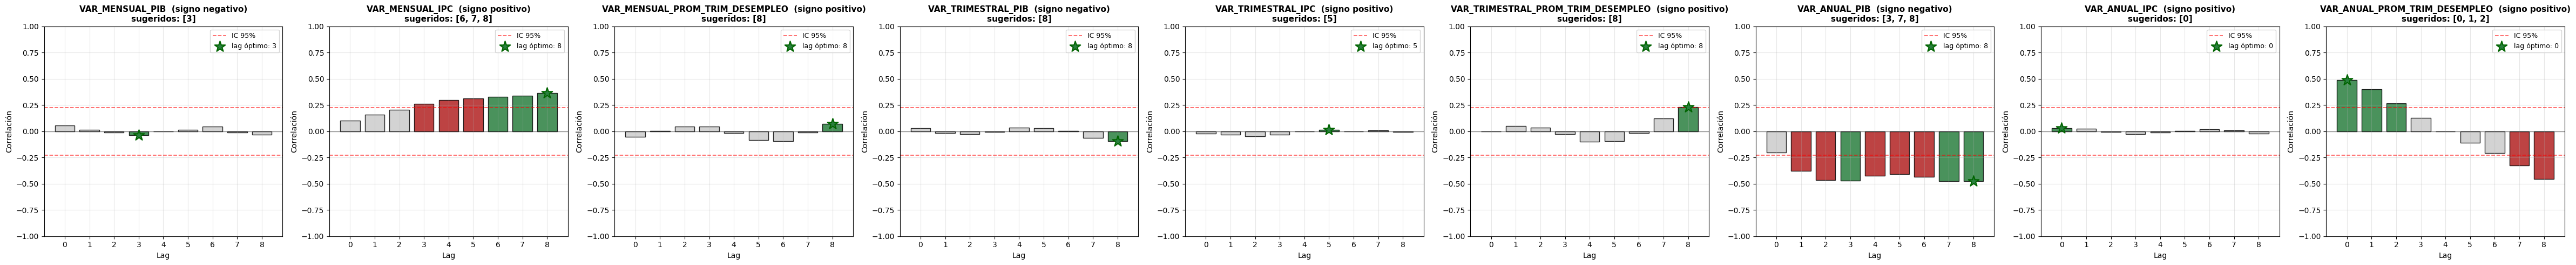

   BLOQUE 3 · TABLA FINAL DE LAGS RECOMENDADOS (una fila por exógena)


,exogena,signo_esperado,escenario,lags_significativos,lags_sugeridos
orden,,,,,
1,VAR_MENSUAL_PIB,negativo,"2 · signo esperado, sin significancia (más cer...",[],[3]
2,VAR_MENSUAL_IPC,positivo,1 · significativos con signo esperado (top 3),"[3, 4, 5, 6, 7, 8]","[6, 7, 8]"
3,VAR_MENSUAL_PROM_TRIM_DESEMPLEO,positivo,"2 · signo esperado, sin significancia (más cer...",[],[8]
4,VAR_TRIMESTRAL_PIB,negativo,"2 · signo esperado, sin significancia (más cer...",[],[8]
5,VAR_TRIMESTRAL_IPC,positivo,"2 · signo esperado, sin significancia (más cer...",[],[5]
6,VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO,positivo,1 · significativos con signo esperado (top 3),[8],[8]
7,VAR_ANUAL_PIB,negativo,1 · significativos con signo esperado (top 3),"[1, 2, 3, 4, 5, 6, 7, 8]","[3, 7, 8]"
8,VAR_ANUAL_IPC,positivo,"2 · signo esperado, sin significancia (más cer...",[],[0]
9,VAR_ANUAL_PROM_TRIM_DESEMPLEO,positivo,1 · significativos con signo esperado (top 3),"[0, 1, 2, 7, 8]","[0, 1, 2]"


VARIABLE FINAL -> lags_por_exogena:
   VAR_MENSUAL_PIB     : [3]
   VAR_MENSUAL_IPC     : [6, 7, 8]
   VAR_MENSUAL_PROM_TRIM_DESEMPLEO: [8]
   VAR_TRIMESTRAL_PIB  : [8]
   VAR_TRIMESTRAL_IPC  : [5]
   VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO: [8]
   VAR_ANUAL_PIB       : [3, 7, 8]
   VAR_ANUAL_IPC       : [0]
   VAR_ANUAL_PROM_TRIM_DESEMPLEO: [0, 1, 2]


In [ ]:
# =====================================================================
# CELDA B3.3 · GRÁFICOS DE VALIDACIÓN + TABLA FINAL + lags_por_exogena
# ---------------------------------------------------------------------
# Correlograma cruzado por exógena (validación visual) y definición de la
# variable final que entra al Bloque 5 (combinaciones).
# =====================================================================

# ----------------- GRÁFICOS: CORRELOGRAMA CRUZADO -------------------
fig, axes = plt.subplots(1, n_exogenas, figsize=(5.3 * n_exogenas, 5), squeeze=False)
axes = axes[0]

for idx, exo in enumerate(nombres_exogenas):
    ax = axes[idx]
    r = resultados_crosscorr[exo]
    lags = list(r['correlaciones'].keys())
    corrs = [r['correlaciones'][l] for l in lags]
    ic = r['ic_bound']

    # Color: verde = sugerido, rojo = significativo (no sugerido), gris = resto
    colores = []
    for l in lags:
        if l in r['lags_sugeridos']:
            colores.append("#2a7f3f")
        elif l in r['detalle']['significativos']:
            colores.append("#b22222")
        else:
            colores.append("#cccccc")

    ax.bar(lags, corrs, color=colores, alpha=0.85, edgecolor="black", linewidth=1)
    ax.axhline(ic, color="red", ls="--", alpha=0.6, lw=1.3, label="IC 95%")
    ax.axhline(-ic, color="red", ls="--", alpha=0.6, lw=1.3)
    ax.axhline(0, color="black", alpha=0.4, lw=1)

    if r['lag_optimo'] is not None:
        lo = r['lag_optimo']
        ax.scatter([lo], [r['correlaciones'][lo]], color="#2a7f3f", s=220,
                   marker="*", edgecolor="darkgreen", linewidth=1.5, zorder=5,
                   label=f"lag óptimo: {lo}")

    ax.set_title(f"{exo}  (signo {r['signo_esperado']})\nsugeridos: {r['lags_sugeridos']}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlación")
    ax.set_xticks(lags)
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------- TABLA FINAL ------------------------------
filas = []
for i, exo in enumerate(nombres_exogenas, start=1):
    r = resultados_crosscorr[exo]
    filas.append({
        "orden": i,
        "exogena": exo,
        "signo_esperado": r['signo_esperado'],
        "escenario": r['escenario'],
        "lags_significativos": r['detalle']['significativos'],
        "lags_sugeridos": r['lags_sugeridos'],
    })
tabla_lags = pd.DataFrame(filas).set_index("orden")

# ------------------- VARIABLE FINAL DEL BLOQUE 3 --------------------
# Diccionario {exógena: [lags]} -> es lo que iterará el Bloque 5 (combinaciones)
lags_por_exogena = {exo: resultados_crosscorr[exo]['lags_sugeridos'] for exo in nombres_exogenas}

print("=" * 80)
print("   BLOQUE 3 · TABLA FINAL DE LAGS RECOMENDADOS (una fila por exógena)")
print("=" * 80)
display(tabla_lags)
print("VARIABLE FINAL -> lags_por_exogena:")
for exo, lags in lags_por_exogena.items():
    print(f"   {exo:<20}: {lags}")
print("=" * 80)


## BLOQUE 4 (DUMMIES) · Variables dummy opcionales

Bloque **opcional**: genera una o varias variables **dummy** (vectores de 0 y 1)
a partir de parámetros básicos: **fecha de inicio** y **fecha de fin** (la dummy
vale 1 dentro de ese rango, 0 fuera).

- Es **una sola celda** y **solo se corre si el usuario quiere** incluir dummies.
- Si la lista queda vacía (o no se corre la celda), el **Bloque 5** entiende que
  **no aplica dummy**.
- Se pueden definir **varias** dummies (cada una con su rango).

Las dummies se generan sobre el **índice completo (histórico + proyección)** para
que sirvan tanto al ajuste (Bloque 5) como al forecast (Bloque 6).

**Variable final → `var_dummies`** (DataFrame con una columna por dummy, o `None`).


In [ ]:
# =====================================================================
# CELDA B4.1 · (OPCIONAL) GENERADOR DE VARIABLES DUMMY
# ---------------------------------------------------------------------
# Corre esta celda SOLO si quieres incluir variables dummy en los modelos.
# Cada dummy = 1 entre 'inicio' y 'fin' (inclusive), 0 en el resto.
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 4).


def generar_dummy(indice, inicio, fin):
    """Vector 0/1 sobre 'indice': 1 si la fecha está en [inicio, fin]."""
    ini = pd.to_datetime(inicio, dayfirst=True)
    fin = pd.to_datetime(fin, dayfirst=True)
    return pd.Series(((indice >= ini) & (indice <= fin)).astype(int), index=indice)


# Índice completo = histórico (endógena) + proyección (escenarios)
indice_completo = var_endogena_orig.index.union(escenarios["BAS"].index)

print("=" * 72)
print("   BLOQUE 4 · VARIABLES DUMMY (opcional)")
print("=" * 72)

if len(DUMMIES) == 0:
    var_dummies = None
    print("No se definieron variables dummy.")
    print("El Bloque 5 entenderá que NO aplica dummy para los modelos.")
else:
    columnas = {}
    for d in DUMMIES:
        nombre = d["nombre"]
        ini, fin = d["inicio"], d["fin"]

        if pd.to_datetime(ini, dayfirst=True) > pd.to_datetime(fin, dayfirst=True):
            raise ValueError(f"Dummy '{nombre}': la fecha inicio ({ini}) es posterior a la fin ({fin}).")
        if nombre in columnas:
            raise ValueError(f"Nombre de dummy duplicado: '{nombre}'.")

        serie = generar_dummy(indice_completo, ini, fin)
        columnas[nombre] = serie

        n_unos = int(serie.sum())
        if n_unos == 0:
            print(f"   [!!] {nombre}: 0 periodos en 1 (el rango {ini}–{fin} no cae en el índice). Revisar.")
        else:
            print(f"   [OK] {nombre}: 1 entre {ini} y {fin}  ->  {n_unos} periodos activos.")

    var_dummies = pd.DataFrame(columnas)

    # --- Validación visual: cada dummy sobre la línea de tiempo ----
    fig, ax = plt.subplots(figsize=(11, 2.2 + 0.4 * len(columnas)))
    for j, nombre in enumerate(var_dummies.columns):
        ax.step(var_dummies.index, var_dummies[nombre] + j * 1.5,
                where="post", lw=1.6, label=nombre)
    ax.axvline(fecha_fin_endo, color="grey", ls=":", lw=1, alpha=0.8,
               label="fin histórico")
    ax.set_title("Variables dummy (0/1) sobre la línea de tiempo")
    ax.set_xlabel("Fecha")
    ax.set_yticks([])
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

# --- Reporte de la variable final -----------------------------------
print("-" * 72)
if var_dummies is None:
    print("var_dummies = None   (sin dummies)")
else:
    print(f"var_dummies -> DataFrame {list(var_dummies.columns)}  "
          f"({var_dummies.shape[0]} filas, histórico + proyección)")
    display(var_dummies[(var_dummies != 0).any(axis=1)])  # filas donde alguna dummy = 1
print("=" * 72)


   BLOQUE 4 · VARIABLES DUMMY (opcional)
No se definieron variables dummy.
El Bloque 5 entenderá que NO aplica dummy para los modelos.
------------------------------------------------------------------------
var_dummies = None   (sin dummies)


## BLOQUE 5 (COMBINACIONES) · Motor de modelos SARIMAX y filtrado

Motor central: genera **todas** las combinaciones de modelos SARIMAX guiadas por
los bloques anteriores, las ajusta sobre el histórico y filtra las que cumplen las
métricas del flujo.

**Insumos guiados:**
- Endógena ya diferenciada → `var_endogena_diff` (en el modelo `d = 0`).
- Exógenas ya diferenciadas → `var_exogenas_diff` (cada una con su `d`).
- Lags por exógena → `lags_por_exogena` (Bloque 3).
- Órdenes `VALORES_P`, `VALORES_Q` (Bloque 2).
- Dummies opcionales → `var_dummies` (Bloque 4; si no existe/está vacío, no aplica).

**Reglas de combinación:** máximo **3 exógenas** por modelo; cada exógena entra con
**un solo lag** (exclusivo). Se combinan subconjuntos de exógenas × (un lag por
exógena) × `p` × `q` × (con/sin dummy).

**Filtros (flujo):**
- `VIF < VIF_MAX` (multicolinealidad).
- **Signos**: el coeficiente de cada exógena debe respetar su signo del Bloque 3 (estricto).
- Los modelos con **orden AR `p = 0`** NO se descartan: se **marcan** (`ar_p_cero`) para
  revisarlos/excluirlos en la exportación (Bloque 8).

Celdas: **(B5.1)** parámetros + recorte temporal, **(B5.2)** combinaciones + conteo total,
**(B5.3)** funciones (exog, VIF, ajuste, signos), **(B5.4)** motor + filtrado + `modelos_aceptados`.


In [ ]:
# =====================================================================
# CELDA B5.1 · PARÁMETROS DEL MOTOR + RECORTE TEMPORAL
# ---------------------------------------------------------------------
# modelo_fecha_inicio: descarta histórico ANTERIOR (datos contaminados).
# modelo_fecha_fin   : límite superior (recorta histórico y, en el Bloque 6,
#                      también la proyección: p.ej. proyectado a 2028 pero solo hasta 2027).
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 5).


def _a_fecha(x):
    return pd.to_datetime(x, dayfirst=True) if x else None


def _recortar(obj, ini, fin):
    if obj is None:
        return None
    out = obj
    if ini is not None:
        out = out[out.index >= ini]
    if fin is not None:
        out = out[out.index <= fin]
    return out


modelo_ini = _a_fecha(MODELO_FECHA_INICIO)
modelo_fin = _a_fecha(MODELO_FECHA_FIN)

# Datos de AJUSTE (histórico ya diferenciado, recortado a la ventana)
endo_model = _recortar(var_endogena_diff, modelo_ini, modelo_fin)
exog_model = _recortar(var_exogenas_diff, modelo_ini, modelo_fin)

# ¿Hay dummies disponibles? (la celda del Bloque 4 es opcional)
dummy_disponible = ('var_dummies' in globals()) and (var_dummies is not None) \
    and (getattr(var_dummies, 'shape', [0, 0])[1] > 0)
dummies_model = _recortar(var_dummies, modelo_ini, modelo_fin) if dummy_disponible else None

# Signo económico esperado por exógena (del Bloque 3)
signo_por_exogena = dict(zip(nombres_exogenas, SIGNOS_EXOGENAS))

# --- Reporte --------------------------------------------------------
print("=" * 72)
print("   BLOQUE 5 · PARÁMETROS DEL MOTOR Y VENTANA DE DATOS")
print("=" * 72)
print(f"Ventana de ajuste (histórico) : {endo_model.dropna().index.min():%d/%m/%Y}  ->  "
      f"{endo_model.dropna().index.max():%d/%m/%Y}  ({endo_model.dropna().shape[0]} obs.)")
print(f"modelo_fecha_inicio           : {MODELO_FECHA_INICIO}")
print(f"modelo_fecha_fin              : {MODELO_FECHA_FIN}")
print(f"Máx. exógenas por modelo      : {MAX_EXOG_POR_MODELO}")
print(f"VIF_MAX                       : {VIF_MAX}")
print(f"Trend SARIMAX                 : '{TREND_MODELO}'")
print(f"Dummies disponibles           : {('sí -> ' + str(list(dummies_model.columns))) if dummy_disponible else 'no'}")
print(f"Signos esperados              : {signo_por_exogena}")
print("=" * 72)


   BLOQUE 5 · PARÁMETROS DEL MOTOR Y VENTANA DE DATOS
Ventana de ajuste (histórico) : 01/01/2019  ->  01/03/2025  (75 obs.)
modelo_fecha_inicio           : None
modelo_fecha_fin              : None
Máx. exógenas por modelo      : 3
VIF_MAX                       : 5.0
Trend SARIMAX                 : 'c'
Dummies disponibles           : no
Signos esperados              : {'VAR_MENSUAL_PIB': 'negativo', 'VAR_MENSUAL_IPC': 'positivo', 'VAR_MENSUAL_PROM_TRIM_DESEMPLEO': 'positivo', 'VAR_TRIMESTRAL_PIB': 'negativo', 'VAR_TRIMESTRAL_IPC': 'positivo', 'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO': 'positivo', 'VAR_ANUAL_PIB': 'negativo', 'VAR_ANUAL_IPC': 'positivo', 'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 'positivo'}


In [ ]:
# =====================================================================
# CELDA B5.2 · GENERACIÓN DE COMBINACIONES + CONTEO TOTAL
# ---------------------------------------------------------------------
# Subconjuntos de exógenas (1..MAX) × un lag por exógena (exclusivo)
#                          × VALORES_P × VALORES_Q × (con/sin dummy)
# =====================================================================

# Exógenas con lags sugeridos disponibles (Bloque 3)
exog_con_lags = {exo: lags for exo, lags in lags_por_exogena.items() if len(lags) > 0}
exog_sin_lags = [exo for exo in nombres_exogenas if exo not in exog_con_lags]
if exog_sin_lags:
    print(f"[!!] Exógenas sin lags sugeridos (no entran a combinaciones): {exog_sin_lags}")

nombres_validos = [e for e in nombres_exogenas if e in exog_con_lags]
max_k = min(MAX_EXOG_POR_MODELO, len(nombres_validos))

# Combinaciones de exógenas×lags (cada exógena con UN lag, exclusivo)
combos_exog = []                 # lista de dicts {exo: lag}
conteo_por_tamano = {}
for k in range(1, max_k + 1):
    cont_k = 0
    for subset in itertools.combinations(nombres_validos, k):
        listas = [[(exo, lag) for lag in exog_con_lags[exo]] for exo in subset]
        for asignacion in itertools.product(*listas):
            combos_exog.append(dict(asignacion))
            cont_k += 1
    conteo_por_tamano[k] = cont_k

# Factor dummy: con/sin si hay dummies; solo "sin" si no aplica (ahorra recursos)
dummy_opciones = [False, True] if dummy_disponible else [False]

n_exog_combos = len(combos_exog)
nP, nQ, nD = len(VALORES_P), len(VALORES_Q), len(dummy_opciones)
total_modelos = n_exog_combos * nP * nQ * nD

# Lista completa de especificaciones a ajustar
especificaciones = []
for combo in combos_exog:
    for p in VALORES_P:
        for q in VALORES_Q:
            for usar_dummy in dummy_opciones:
                especificaciones.append({'exogenas': combo, 'p': p, 'q': q, 'usar_dummy': usar_dummy})

# --- Impresión del conteo (multiplicaciones que definen el total) ---
print("=" * 72)
print("   BLOQUE 5 · CONTEO DE MODELOS A GENERAR")
print("=" * 72)
print("Combinaciones de exógenas×lags por tamaño de subconjunto:")
for k, c in conteo_por_tamano.items():
    print(f"   {k} exógena(s): {c}")
print(f"   --------------------------------")
print(f"   Total combos exógenas×lags = {n_exog_combos}")
print("-" * 72)
print(f"Órdenes P = {VALORES_P}  (|P| = {nP})")
print(f"Órdenes Q = {VALORES_Q}  (|Q| = {nQ})")
print(f"Dummy     = {'con/sin (×2)' if dummy_disponible else 'no aplica (×1)'}  (factor = {nD})")
print("-" * 72)
print(f"TOTAL DE MODELOS = {n_exog_combos} × {nP} × {nQ} × {nD} = {total_modelos}")
print("=" * 72)

assert len(especificaciones) == total_modelos


   BLOQUE 5 · CONTEO DE MODELOS A GENERAR
Combinaciones de exógenas×lags por tamaño de subconjunto:
   1 exógena(s): 15
   2 exógena(s): 96
   3 exógena(s): 344
   --------------------------------
   Total combos exógenas×lags = 455
------------------------------------------------------------------------
Órdenes P = [0, 1, 2]  (|P| = 3)
Órdenes Q = [0, 1, 2]  (|Q| = 3)
Dummy     = no aplica (×1)  (factor = 1)
------------------------------------------------------------------------
TOTAL DE MODELOS = 455 × 3 × 3 × 1 = 4095


In [ ]:
# =====================================================================
# CELDA B5.3 · FUNCIONES · EXÓGENAS, VIF, AJUSTE SARIMAX Y SIGNOS
# ---------------------------------------------------------------------
# Sin valores por defecto: los parámetros se pasan al llamarlas (B5.4).
# =====================================================================

# Construye la matriz exógena de una combinación: cada exógena con su lag (col '{exo}_lag{lag}')
def construir_exog(combo_lags, fuente_exog, dummies, usar_dummy):
    columnas = {}
    for exo, lag in combo_lags.items():
        columnas[f"{exo}_lag{lag}"] = fuente_exog[exo].shift(lag)
    X = pd.DataFrame(columnas)
    if usar_dummy and dummies is not None:
        X = X.join(dummies, how="left")
    return X


# Alinea endógena y exógenas, elimina NaN y columnas constantes (p.ej. dummy fuera de ventana)
def preparar_fit(endog, X):
    df = pd.concat([endog.rename("__y__"), X], axis=1).dropna()
    y = df["__y__"]
    Xc = df.drop(columns="__y__")
    Xc = Xc.loc[:, Xc.nunique() > 1]   # quita columnas sin variación
    return y, Xc


# VIF máximo entre los regresores (con constante auxiliar). <2 columnas -> VIF=1
def calcular_vif_max(X):
    if X.shape[1] < 2:
        return 1.0, {col: 1.0 for col in X.columns}
    Xconst = add_constant(X, has_constant="add")
    vifs = {}
    for i, col in enumerate(Xconst.columns):
        if col == "const":
            continue
        vifs[col] = variance_inflation_factor(Xconst.values, i)
    return (max(vifs.values()) if vifs else 1.0), vifs


# Ajusta SARIMAX(p, 0, q) con exógenas. Devuelve el resultado o None si falla.
def ajustar_sarimax(y, X, p, q, trend):
    try:
        modelo = SARIMAX(y, exog=X, order=(p, 0, q), trend=trend,
                         enforce_stationarity=False, enforce_invertibility=False)
        return modelo.fit(disp=False)
    except Exception:
        return None


# Verifica que TODAS las exógenas del modelo respeten su signo esperado (Bloque 3)
def signos_ok(resultado, combo_lags, signo_por_exo):
    for exo, lag in combo_lags.items():
        col = f"{exo}_lag{lag}"
        if col not in resultado.params.index:
            return False
        coef = resultado.params[col]
        esperado = signo_por_exo[exo]
        if esperado == "positivo" and coef < 0:
            return False
        if esperado == "negativo" and coef > 0:
            return False
    return True


print("Funciones del motor SARIMAX cargadas correctamente.")


Funciones del motor SARIMAX cargadas correctamente.


In [ ]:
# =====================================================================
# CELDA B5.4 · MOTOR: AJUSTE + FILTROS + MODELOS ACEPTADOS
# ---------------------------------------------------------------------
# Ajusta cada especificación, aplica VIF y signos, y marca p=0 (ar_p_cero).
# Variable final -> modelos_aceptados (con el modelo ajustado para el Bloque 6).
# =====================================================================

modelos_aceptados = []
n_fallidos = 0
n_rech_vif = 0
n_rech_signos = 0
log_cada = max(1, total_modelos // 20)

print(f"Ajustando {total_modelos} modelos...")
for i, spec in enumerate(especificaciones, start=1):
    X = construir_exog(spec['exogenas'], exog_model, dummies_model, spec['usar_dummy'])
    y, Xc = preparar_fit(endo_model, X)

    if len(y) < 10 or Xc.shape[1] == 0:
        n_fallidos += 1
    else:
        res = ajustar_sarimax(y, Xc, spec['p'], spec['q'], TREND_MODELO)
        if res is None:
            n_fallidos += 1
        else:
            vif_max, _ = calcular_vif_max(Xc)
            if vif_max >= VIF_MAX:
                n_rech_vif += 1
            elif not signos_ok(res, spec['exogenas'], signo_por_exogena):
                n_rech_signos += 1
            else:
                modelos_aceptados.append({
                    'id': i,
                    'exogenas': spec['exogenas'],          # {exo: lag}
                    'p': spec['p'], 'q': spec['q'],
                    'usar_dummy': spec['usar_dummy'],
                    'ar_p_cero': spec['p'] == 0,           # bandera para la exportación (Bloque 8)
                    'n_obs': int(len(y)),
                    'aic': float(res.aic), 'bic': float(res.bic),
                    'vif_max': float(vif_max),
                    'resultado': res,                       # modelo ajustado (para el forecast)
                })

    if i % log_cada == 0 or i == total_modelos:
        print(f"   ... {i}/{total_modelos} evaluados | aceptados={len(modelos_aceptados)}")

# --- Tabla resumen de aceptados (ordenada por AIC) ------------------
filas = []
for m in modelos_aceptados:
    filas.append({
        'id': m['id'],
        'exogenas_lags': m['exogenas'],
        'p': m['p'], 'q': m['q'],
        'dummy': m['usar_dummy'],
        'ar_p_cero': m['ar_p_cero'],
        'n_obs': m['n_obs'],
        'aic': round(m['aic'], 3),
        'bic': round(m['bic'], 3),
        'vif_max': round(m['vif_max'], 3),
    })
tabla_modelos = pd.DataFrame(filas)
if not tabla_modelos.empty:
    tabla_modelos = tabla_modelos.sort_values('aic').reset_index(drop=True)

# --- Reporte final --------------------------------------------------
print("=" * 72)
print("   BLOQUE 5 · RESULTADO DEL MOTOR")
print("=" * 72)
print(f"Total evaluados        : {total_modelos}")
print(f"   Fallidos al ajustar : {n_fallidos}")
print(f"   Rechazados por VIF   : {n_rech_vif}  (VIF >= {VIF_MAX})")
print(f"   Rechazados por signo : {n_rech_signos}")
print(f"   ACEPTADOS            : {len(modelos_aceptados)}")
print(f"      de ellos con p=0  : {sum(m['ar_p_cero'] for m in modelos_aceptados)}  (marcados para revisar en exportación)")
print("-" * 72)
print("VARIABLE FINAL -> modelos_aceptados (lista con el modelo ajustado)")
print("Vista previa (tabla_modelos, ordenada por AIC):")
display(tabla_modelos.head(15))
print("=" * 72)


Ajustando 4095 modelos...
   ... 204/4095 evaluados | aceptados=129
   ... 408/4095 evaluados | aceptados=231
   ... 612/4095 evaluados | aceptados=325
   ... 816/4095 evaluados | aceptados=394
   ... 1020/4095 evaluados | aceptados=517
   ... 1224/4095 evaluados | aceptados=620
   ... 1428/4095 evaluados | aceptados=679
   ... 1632/4095 evaluados | aceptados=774
   ... 1836/4095 evaluados | aceptados=848
   ... 2040/4095 evaluados | aceptados=869
   ... 2244/4095 evaluados | aceptados=891
   ... 2448/4095 evaluados | aceptados=995
   ... 2652/4095 evaluados | aceptados=1066
   ... 2856/4095 evaluados | aceptados=1188
   ... 3060/4095 evaluados | aceptados=1303
   ... 3264/4095 evaluados | aceptados=1315
   ... 3468/4095 evaluados | aceptados=1336
   ... 3672/4095 evaluados | aceptados=1381
   ... 3876/4095 evaluados | aceptados=1466
   ... 4080/4095 evaluados | aceptados=1570
   ... 4095/4095 evaluados | aceptados=1574
   BLOQUE 5 · RESULTADO DEL MOTOR
Total evaluados        : 4095
  

,id,exogenas_lags,p,q,dummy,ar_p_cero,n_obs,aic,bic,vif_max
0,126,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 1},2,2,False,False,75,-428.633,-412.696,1.000
1,115,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 0},2,0,False,False,75,-428.123,-416.671,1.000
2,124,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 1},2,0,False,False,75,-427.608,-416.156,1.000
3,123,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 1},1,2,False,False,75,-427.265,-413.605,1.000
4,979,"{'VAR_ANUAL_IPC': 0, 'VAR_ANUAL_PROM_TRIM_DESE...",2,0,False,False,75,-426.906,-413.163,1.003
5,116,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 0},2,1,False,False,75,-426.862,-413.119,1.000
6,988,"{'VAR_ANUAL_IPC': 0, 'VAR_ANUAL_PROM_TRIM_DESE...",2,0,False,False,75,-426.377,-412.635,1.001
7,125,{'VAR_ANUAL_PROM_TRIM_DESEMPLEO': 1},2,1,False,False,75,-426.222,-412.479,1.000
8,980,"{'VAR_ANUAL_IPC': 0, 'VAR_ANUAL_PROM_TRIM_DESE...",2,1,False,False,75,-425.498,-409.464,1.003
9,989,"{'VAR_ANUAL_IPC': 0, 'VAR_ANUAL_PROM_TRIM_DESE...",2,1,False,False,75,-424.891,-408.858,1.001


## BLOQUE 6 (FORECAST) · Proyección de los modelos aceptados

Se proyecta cada modelo de `modelos_aceptados` sobre los **tres escenarios**
(BAS/ADV/OPT) y se **revierte la transformación** de la endógena para volver a su
escala original.

**Transformación consistente de las exógenas (clave):** las proyecciones de
`escenarios` están en **niveles**. Para cada exógena se diferencia la serie
`[histórico + proyección]` con **su misma `d`** (`var_exogenas_d`) y se aplica el
**mismo lag** del modelo — así la primera proyección enlaza con el último histórico.

**Reversión de la endógena (orden del flujo):**
1. Des-diferenciar el forecast con `var_endogena_d` (integración acumulada).
2. Si la endógena fue **logit**, aplicar la inversa: `y = 1 / (1 + e^{-x})`.

**Columnas exactas:** se reconstruyen las columnas con que se ajustó cada modelo
(respetando el descarte de columnas constantes de B5) para que `get_forecast`
reciba el exógeno correcto.

**Variable final → `forecasts_por_modelo`**: `{id_modelo: DataFrame[BAS, ADV, OPT]}`
en la escala original de la endógena (insumo del Bloque 7).


In [ ]:
# =====================================================================
# CELDA B6.1 · FUNCIONES · REVERSIÓN Y EXÓGENAS FUTURAS
# ---------------------------------------------------------------------
# Reutiliza aplicar_diferenciacion (B1.1) y construir_exog/preparar_fit (B5.3).
# =====================================================================

# Revierte la diferenciación (orden d) de un forecast, integrando desde el nivel histórico transformado (último(s) valor(es) de entrenamiento).
def revertir_diferenciacion(forecast_diff_valores, nivel_hist, d):
    current = np.asarray(forecast_diff_valores, dtype=float)
    for k in range(d, 0, -1):
        lower = nivel_hist.copy()
        for _ in range(k - 1):
            lower = lower.diff()
        seed = lower.dropna().iloc[-1]
        current = seed + np.cumsum(current)
    return current


# Construye la matriz exógena FUTURA (diferenciada + rezagada) de un escenario, usando exactamente las columnas con que se ajustó el modelo (cols_modelo).
def construir_exog_futuro(combo_lags, escenario_niveles, exog_hist_niveles, d_por_exo,
                          dummies_full, usar_dummy, cols_modelo, fechas_forecast):
    fut = {}
    for exo, lag in combo_lags.items():
        col = f"{exo}_lag{lag}"
        if col not in cols_modelo:
            continue
        # Diferencia la serie [histórico + proyección] con la d de la exógena y rezaga
        serie_completa = pd.concat([exog_hist_niveles[exo], escenario_niveles[exo]])
        serie_diff = aplicar_diferenciacion(serie_completa, d_por_exo[exo]).shift(lag)
        fut[col] = serie_diff.reindex(fechas_forecast)
    if usar_dummy and dummies_full is not None:
        for dcol in dummies_full.columns:
            if dcol in cols_modelo:
                fut[dcol] = dummies_full[dcol].reindex(fechas_forecast)
    return pd.DataFrame(fut).reindex(columns=cols_modelo)


# Bloquea el solapamiento de los escenarios laterales (ADV/OPT) contra el BASE:
# si en alguna observación el escenario se cruza hacia el lado contrario al que
# predomina sobre el horizonte (es decir, 'se va a cruzar' con el base), esa
# observación se iguala al BAS para evitar el solapamiento de las proyecciones.
#   fc             : DataFrame con el forecast de la endógena por escenario (cols. BAS/ADV/OPT)
#   col_base       : nombre de la columna del escenario base
#   escenarios_lado: escenarios laterales a controlar contra el base
#   Devuelve: (fc_ajustado, dict {escenario: nº de observaciones igualadas al base})
def bloquear_solapamiento_escenarios(fc, col_base, escenarios_lado):
    fc = fc.copy()
    if col_base not in fc.columns:
        return fc, {}
    base = fc[col_base]
    ajustes = {}
    for esc in escenarios_lado:
        if esc not in fc.columns:
            continue
        dif = fc[esc] - base
        # Lado esperado = signo dominante de (escenario - base) sobre el horizonte
        signo = np.sign(dif.sum())
        if signo == 0 and (dif != 0).any():
            signo = np.sign(dif[dif != 0].iloc[0])
        if signo > 0:        # el escenario debe quedar POR ENCIMA del base
            cruza = fc[esc] < base
        elif signo < 0:      # el escenario debe quedar POR DEBAJO del base
            cruza = fc[esc] > base
        else:                # escenario identico al base: nada que ajustar
            cruza = pd.Series(False, index=fc.index)
        fc.loc[cruza, esc] = base[cruza]
        ajustes[esc] = int(cruza.sum())
    return fc, ajustes


print("Funciones de forecast (reversión, exógenas futuras y bloqueo de solapamiento) cargadas correctamente.")


Funciones de forecast (reversión, exógenas futuras y bloqueo de solapamiento) cargadas correctamente.


In [ ]:
# =====================================================================
# CELDA B6.2 · PARÁMETROS + EJECUCIÓN DEL FORECAST (todos los aceptados)
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 6).

# --- Nivel histórico transformado (para revertir), hasta el fin del entrenamiento ---
if var_endogena_transformacion == 'logit':
    nivel_hist_transf = np.log(var_endogena_orig / (1 - var_endogena_orig)).astype(float)
else:
    nivel_hist_transf = var_endogena_orig.astype(float)

last_train_date = endo_model.dropna().index.max()
nivel_hist_transf = nivel_hist_transf.loc[:last_train_date]

if modelo_fin is not None and modelo_fin < fecha_fin_endo:
    print("[!!] modelo_fecha_fin es anterior al fin del histórico: el forecast de los")
    print("     escenarios podría no ser contiguo. Usa modelo_fecha_fin dentro de la proyección.")

# --- Forecast de cada modelo aceptado en cada escenario -------------
# Bloqueo de solapamiento: parametrizado en la sección de parámetros (Bloque 6):
#   ESCENARIO_BASE, BLOQUEAR_SOLAPAMIENTO_BASE, ESCENARIOS_BLOQUEO_SOLAPE
_ajustes_solape_total = {}
forecasts_por_modelo = {}

if len(modelos_aceptados) == 0:
    print("No hay modelos aceptados para proyectar (revisar Bloque 5).")
else:
    print(f"Proyectando {len(modelos_aceptados)} modelo(s) en {len(ESCENARIOS_FORECAST)} escenario(s)...")
    for m in modelos_aceptados:
        res = m['resultado']

        # Columnas EXACTAS con que se ajustó el modelo (mismas que en B5.4)
        X_hist = construir_exog(m['exogenas'], exog_model, dummies_model, m['usar_dummy'])
        _, Xc_fit = preparar_fit(endo_model, X_hist)
        cols_modelo = list(Xc_fit.columns)

        fc_por_esc = {}
        for esc in ESCENARIOS_FORECAST:
            idx_proy = escenarios[esc].index
            fechas_forecast = idx_proy[idx_proy > last_train_date]
            if modelo_fin is not None:
                fechas_forecast = fechas_forecast[fechas_forecast <= modelo_fin]

            X_fut = construir_exog_futuro(
                combo_lags=m['exogenas'],
                escenario_niveles=escenarios[esc],
                exog_hist_niveles=var_exogenas_orig,
                d_por_exo=var_exogenas_d,
                dummies_full=(var_dummies if dummy_disponible else None),
                usar_dummy=m['usar_dummy'],
                cols_modelo=cols_modelo,
                fechas_forecast=fechas_forecast,
            )

            pred = res.get_forecast(steps=len(fechas_forecast), exog=X_fut.values)
            fc_diff = np.asarray(pred.predicted_mean)

            # Revertir: 1) des-diferenciar, 2) des-logit si aplica
            nivel_fc = revertir_diferenciacion(fc_diff, nivel_hist_transf, var_endogena_d)
            if var_endogena_transformacion == 'logit':
                nivel_fc = 1.0 / (1.0 + np.exp(-nivel_fc))

            fc_por_esc[esc] = pd.Series(nivel_fc, index=fechas_forecast)

        fc_df = pd.DataFrame(fc_por_esc)[ESCENARIOS_FORECAST]

        # --- Bloqueo de solapamiento: el lateral configurado no cruza el BAS ---------
        if BLOQUEAR_SOLAPAMIENTO_BASE:
            fc_df, _aj = bloquear_solapamiento_escenarios(
                fc_df, col_base=ESCENARIO_BASE,
                escenarios_lado=[e for e in ESCENARIOS_BLOQUEO_SOLAPE if e in ESCENARIOS_FORECAST],
            )
            for _e, _n in _aj.items():
                if _n:
                    _ajustes_solape_total[_e] = _ajustes_solape_total.get(_e, 0) + _n

        forecasts_por_modelo[m['id']] = fc_df

    print(f"Forecast completado para {len(forecasts_por_modelo)} modelo(s).")
    print(f"Horizonte: {last_train_date:%d/%m/%Y} (último histórico) -> "
          f"{list(forecasts_por_modelo.values())[0].index.max():%d/%m/%Y}")
    if BLOQUEAR_SOLAPAMIENTO_BASE and _ajustes_solape_total:
        _resumen = ", ".join(f"{_e}: {_n} obs." for _e, _n in _ajustes_solape_total.items())
        print(f"Bloqueo de solapamiento aplicado (obs. igualadas al BAS) -> {_resumen}")


Proyectando 1574 modelo(s) en 3 escenario(s)...
Forecast completado para 1574 modelo(s).
Horizonte: 01/03/2025 (último histórico) -> 01/12/2028
Bloqueo de solapamiento aplicado (obs. igualadas al BAS) -> ADV: 1694 obs.


## BLOQUE 7 (ORDENAMIENTO) · Sensibilidad de escenarios y filtrado

Se descartan los modelos de **baja sensibilidad**: aquellos cuyas proyecciones de
los escenarios **optimista** y **adverso** se parecen demasiado (no diferencian los
escenarios).

**Métrica (flujo):** promedio de la proyección de cada escenario y diferencia
`OPT − ADV`. Como la separación puede tener cualquier signo según la endógena, se
mide con su **magnitud**:

`sensibilidad = |media(OPT) − media(ADV)|`  sobre el horizonte de forecast.

- Se **ordena** de mayor a menor sensibilidad.
- Se **filtran** los modelos con `sensibilidad < UMBRAL_SENSIBILIDAD` (flujo: 0.00005).

**Variable final → `modelos_finales`**: lista (ordenada por sensibilidad) de los
modelos que pasan, con sus métricas y su forecast — insumo del Bloque 8 (exportación).


In [ ]:
# =====================================================================
# CELDA B7.1 · SENSIBILIDAD + OUTLIERS + SIGNIFICANCIA + ORDENAMIENTO
# ---------------------------------------------------------------------
# Cuatro filtros:
#   (1) sensibilidad   = |media(OPT) - media(ADV)| >= UMBRAL_SENSIBILIDAD
#   (2) sin outliers   = todo el forecast dentro de media_hist ± K*std_hist
#   (3) significancia  = al menos UNA exógena del modelo con p-value <= PVALUE_SIGNIF_EXOG
#                        (se aplica solo si FILTRO_SIGNIF_EXOG = True)
#   (4) factor FWL     = todo factor (forecast/última PD) dentro de [FWL_FACTOR_MIN, FWL_FACTOR_MAX]
#                        (se aplica solo si FILTRO_FWL = True)
# La tabla final conserva SOLO los modelos que pasan los filtros activos.
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 7).

if len(forecasts_por_modelo) == 0:
    print("No hay forecasts (Bloque 6) para evaluar.")
    tabla_sensibilidad = pd.DataFrame()
else:
    # --- Banda de plausibilidad: histórico de la endógena en la ventana de ajuste ---
    serie_ref = var_endogena_orig.loc[:last_train_date]
    if modelo_ini is not None:
        serie_ref = serie_ref[serie_ref.index >= modelo_ini]
    media_hist = serie_ref.mean()
    std_hist = serie_ref.std()
    lim_inf = media_hist - DESV_ESTANDAR_OUTLIER * std_hist
    lim_sup = media_hist + DESV_ESTANDAR_OUTLIER * std_hist
    last_pd_b7 = var_endogena_orig.loc[last_train_date]   # última PD observada (para el factor FWL)

    filas = []
    for m in modelos_aceptados:
        if m['id'] not in forecasts_por_modelo:
            continue
        fc = forecasts_por_modelo[m['id']]
        media_bas = fc['BAS'].mean()
        media_adv = fc['ADV'].mean()
        media_opt = fc['OPT'].mean()
        diferencia = media_opt - media_adv
        sensibilidad = abs(diferencia)

        vmin = float(fc.values.min())
        vmax = float(fc.values.max())
        pasa_sensibilidad = sensibilidad >= UMBRAL_SENSIBILIDAD
        pasa_outlier = (vmin >= lim_inf) and (vmax <= lim_sup)

        # --- Factor FWL: forecast (escala original) / última PD observada (misma lógica que B9.1) ---
        fwl_fact = fc.values.ravel() / last_pd_b7
        fwl_fact = fwl_fact[~np.isnan(fwl_fact)]
        fwl_min = float(fwl_fact.min()) if len(fwl_fact) else np.nan
        fwl_max = float(fwl_fact.max()) if len(fwl_fact) else np.nan
        # Rechaza si algún factor FWL cae por debajo de FWL_FACTOR_MIN o por encima de FWL_FACTOR_MAX
        pasa_fwl = (not FILTRO_FWL) or (len(fwl_fact) > 0 and fwl_min >= FWL_FACTOR_MIN and fwl_max <= FWL_FACTOR_MAX)

        # --- Significancia de las exógenas participantes (p-value de cada {exo}_lag{lag}) ---
        res = m['resultado']
        exog_cols = [f"{exo}_lag{lag}" for exo, lag in m['exogenas'].items()]
        pvals_exog = [float(res.pvalues[c]) for c in exog_cols if c in res.pvalues.index]
        pvals_validos = [pv for pv in pvals_exog if pd.notna(pv)]
        pvalue_min_exog = min(pvals_validos) if pvals_validos else np.nan
        n_exog_signif = sum(1 for pv in pvals_validos if pv <= PVALUE_SIGNIF_EXOG)
        # Pasa si el filtro está apagado, o si al menos una exógena es significativa
        pasa_signif = (not FILTRO_SIGNIF_EXOG) or (n_exog_signif >= 1)

        filas.append({
            'id': m['id'],
            'exogenas_lags': m['exogenas'],
            'p': m['p'], 'q': m['q'],
            'dummy': m['usar_dummy'],
            'ar_p_cero': m['ar_p_cero'],
            'aic': round(m['aic'], 3),
            'media_ADV': media_adv,
            'media_BAS': media_bas,
            'media_OPT': media_opt,
            'diferencia_OPT_ADV': diferencia,
            'sensibilidad': sensibilidad,
            'min_fc': vmin,
            'max_fc': vmax,
            'pvalue_min_exog': pvalue_min_exog,
            'n_exog_signif': n_exog_signif,
            'fwl_min': fwl_min,
            'fwl_max': fwl_max,
            'pasa_sensibilidad': pasa_sensibilidad,
            'pasa_outlier': pasa_outlier,
            'pasa_signif': pasa_signif,
            'pasa_fwl': pasa_fwl,
            'pasa': pasa_sensibilidad and pasa_outlier and pasa_signif and pasa_fwl,
        })

    tabla_completa = pd.DataFrame(filas)
    n_total = len(tabla_completa)
    n_desc_sens = int((~tabla_completa['pasa_sensibilidad']).sum())
    n_desc_out = int((tabla_completa['pasa_sensibilidad'] & ~tabla_completa['pasa_outlier']).sum())
    n_desc_signif = int((tabla_completa['pasa_sensibilidad'] & tabla_completa['pasa_outlier']
                         & ~tabla_completa['pasa_signif']).sum())
    n_desc_fwl = int((tabla_completa['pasa_sensibilidad'] & tabla_completa['pasa_outlier']
                      & tabla_completa['pasa_signif'] & ~tabla_completa['pasa_fwl']).sum())
    n_pasa = int(tabla_completa['pasa'].sum())

    # Tabla final: SOLO los que pasan los filtros, ordenada por sensibilidad
    cols_salida = ['id', 'exogenas_lags', 'p', 'q', 'dummy', 'ar_p_cero', 'aic',
                   'media_ADV', 'media_BAS', 'media_OPT',
                   'diferencia_OPT_ADV', 'sensibilidad', 'min_fc', 'max_fc',
                   'fwl_min', 'fwl_max',
                   'pvalue_min_exog', 'n_exog_signif']
    tabla_sensibilidad = (tabla_completa[tabla_completa['pasa']]
                          .sort_values('sensibilidad', ascending=False)
                          .reset_index(drop=True)[cols_salida])

    print("=" * 80)
    print("   BLOQUE 7 · SENSIBILIDAD + OUTLIERS + SIGNIFICANCIA")
    print("=" * 80)
    print(f"Umbral de sensibilidad : {UMBRAL_SENSIBILIDAD}")
    print(f"Banda de outliers      : media_hist ± {DESV_ESTANDAR_OUTLIER}·std")
    print(f"   media_hist={media_hist:.6f} | std_hist={std_hist:.6f}")
    print(f"   límites = [{lim_inf:.6f} , {lim_sup:.6f}]")
    if FILTRO_SIGNIF_EXOG:
        print(f"Significancia exógenas : al menos 1 con p-value <= {PVALUE_SIGNIF_EXOG}")
    else:
        print("Significancia exógenas : filtro DESACTIVADO (FILTRO_SIGNIF_EXOG=False)")
    if FILTRO_FWL:
        print(f"Factor FWL             : todos dentro de [{FWL_FACTOR_MIN} , {FWL_FACTOR_MAX}]")
    else:
        print("Factor FWL             : filtro DESACTIVADO (FILTRO_FWL=False)")
    print("-" * 80)
    print(f"Modelos evaluados                            : {n_total}")
    print(f"   Descartados por baja sensibilidad         : {n_desc_sens}")
    print(f"   Descartados por outlier (de los demás)    : {n_desc_out}")
    print(f"   Descartados por significancia (de los demás): {n_desc_signif}")
    print(f"   Descartados por factor FWL (de los demás) : {n_desc_fwl}")
    print(f"   PASAN todos los filtros activos           : {n_pasa}")
    print("-" * 80)
    print("Tabla final (solo los que pasan, ordenada por sensibilidad):")
    display(tabla_sensibilidad.round(6))
    print("=" * 80)

   BLOQUE 7 · SENSIBILIDAD + OUTLIERS + SIGNIFICANCIA
Umbral de sensibilidad : 5e-05
Banda de outliers      : media_hist ± 2·std
   media_hist=0.016354 | std_hist=0.005708
   límites = [0.004938 , 0.027770]
Significancia exógenas : al menos 1 con p-value <= 0.05
Factor FWL             : todos dentro de [0.8 , 1.3]
--------------------------------------------------------------------------------
Modelos evaluados                            : 1574
   Descartados por baja sensibilidad         : 393
   Descartados por outlier (de los demás)    : 64
   Descartados por significancia (de los demás): 419
   Descartados por factor FWL (de los demás) : 689
   PASAN todos los filtros activos           : 9
--------------------------------------------------------------------------------
Tabla final (solo los que pasan, ordenada por sensibilidad):


,id,exogenas_lags,p,q,dummy,ar_p_cero,aic,media_ADV,media_BAS,media_OPT,diferencia_OPT_ADV,sensibilidad,min_fc,max_fc,fwl_min,fwl_max,pvalue_min_exog,n_exog_signif
0,2852,"{'VAR_MENSUAL_IPC': 7, 'VAR_ANUAL_PIB': 7, 'VA...",2,1,False,False,-379.949,0.012414,0.011569,0.010866,-0.001548,0.001548,0.009636,0.013094,0.843086,1.145671,0.000002,2
1,2591,"{'VAR_MENSUAL_IPC': 6, 'VAR_TRIMESTRAL_PROM_TR...",2,1,False,False,-361.201,0.011960,0.011254,0.010668,-0.001292,0.001292,0.009562,0.012539,0.836611,1.097113,0.002330,1
2,1997,"{'VAR_MENSUAL_IPC': 8, 'VAR_MENSUAL_PROM_TRIM_...",2,1,False,False,-347.599,0.011580,0.010945,0.010415,-0.001165,0.001165,0.009655,0.012615,0.844730,1.103738,0.021984,2
3,3311,"{'VAR_MENSUAL_PROM_TRIM_DESEMPLEO': 8, 'VAR_AN...",2,1,False,False,-382.705,0.011524,0.010944,0.010418,-0.001107,0.001107,0.009454,0.011745,0.827146,1.027632,0.000036,1
4,845,"{'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO': 8, 'VAR...",2,1,False,False,-385.637,0.012656,0.012114,0.011614,-0.001043,0.001043,0.011279,0.014030,0.986865,1.227554,0.000219,1
5,854,"{'VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO': 8, 'VAR...",2,1,False,False,-377.068,0.012955,0.012494,0.012065,-0.000890,0.000890,0.011321,0.014657,0.990465,1.282400,0.028321,1
6,3581,"{'VAR_TRIMESTRAL_PIB': 8, 'VAR_ANUAL_PIB': 3, ...",2,1,False,False,-383.106,0.011438,0.011032,0.010654,-0.000784,0.000784,0.009677,0.011643,0.846709,1.018664,0.002028,1
7,3833,"{'VAR_TRIMESTRAL_IPC': 5, 'VAR_ANUAL_PIB': 8, ...",2,1,False,False,-335.300,0.011390,0.011001,0.010636,-0.000754,0.000754,0.010077,0.011939,0.881654,1.044584,0.000000,2
8,1448,"{'VAR_MENSUAL_PIB': 3, 'VAR_TRIMESTRAL_PIB': 8...",2,1,False,False,-385.666,0.011034,0.010658,0.010307,-0.000727,0.000727,0.009233,0.011389,0.807821,0.996433,0.005326,1


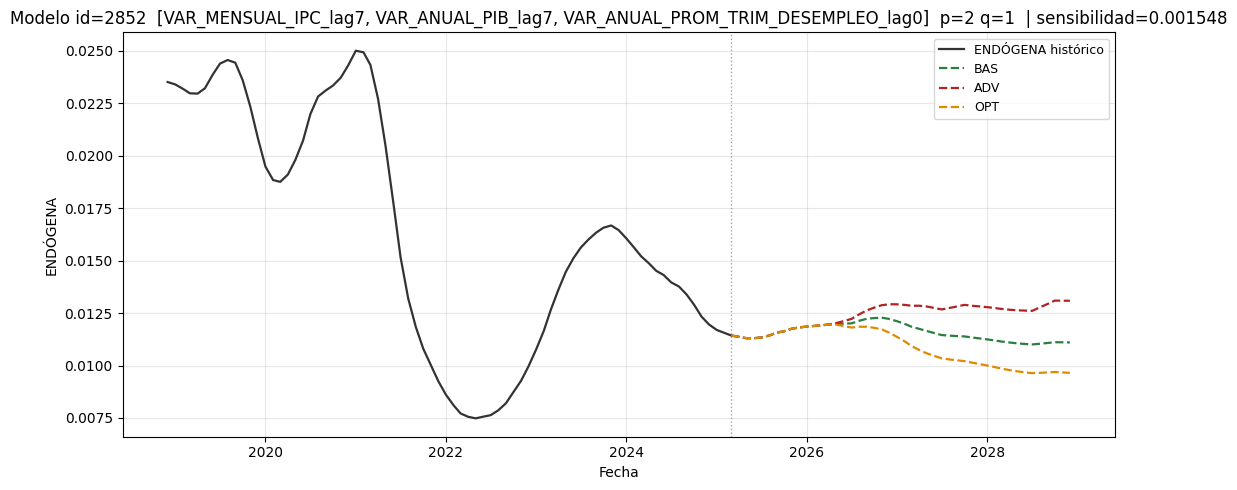

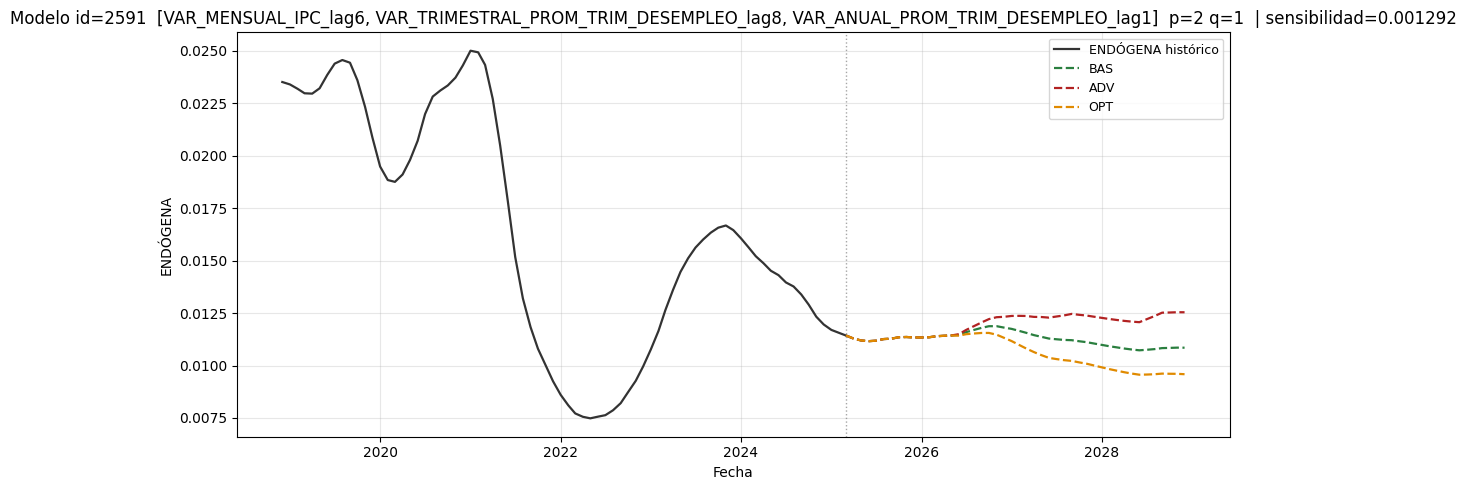

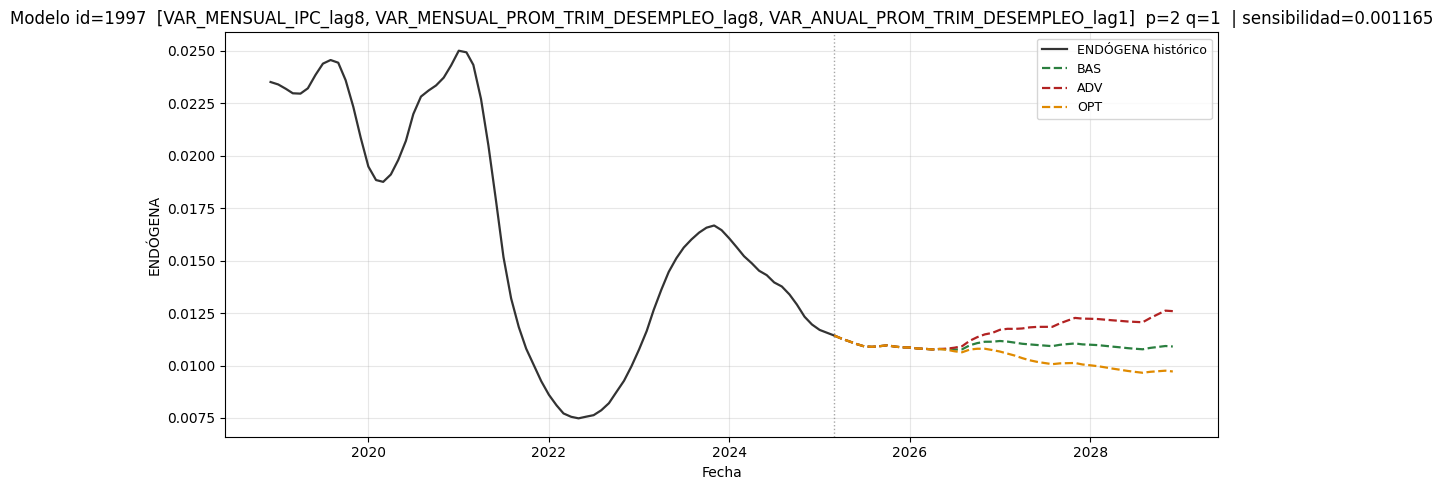

   BLOQUE 7 · VARIABLE FINAL
modelos_finales -> 9 modelo(s) que pasan ambos filtros,
   ordenados de mayor a menor sensibilidad. Cada item trae su forecast (BAS/ADV/OPT).
Se graficaron los 3 más sensibles.


In [ ]:
# =====================================================================
# CELDA B7.2 · GRÁFICAS DE LOS MÁS SENSIBLES + VARIABLE FINAL
# ---------------------------------------------------------------------
# Estilo B6.3: histórico + 3 escenarios para los TOP modelos más sensibles
# (tabla_sensibilidad ya viene filtrada y ordenada de mayor a menor).
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 7).

if tabla_sensibilidad.empty:
    modelos_finales = []
    print("Sin modelos que pasen los filtros del Bloque 7.")
else:
    # --- Variable final: todos los de tabla_sensibilidad (ya pasan), ordenados ----
    modelos_finales = []
    for _, row in tabla_sensibilidad.iterrows():
        m = next(mm for mm in modelos_aceptados if mm['id'] == row['id'])
        modelos_finales.append({
            'id': m['id'],
            'exogenas': m['exogenas'],
            'p': m['p'], 'q': m['q'],
            'usar_dummy': m['usar_dummy'],
            'ar_p_cero': m['ar_p_cero'],
            'aic': m['aic'], 'bic': m['bic'],
            'sensibilidad': float(row['sensibilidad']),
            'diferencia_OPT_ADV': float(row['diferencia_OPT_ADV']),
            'forecast': forecasts_por_modelo[m['id']],   # DataFrame BAS/ADV/OPT (escala original)
        })

    # --- Gráficas de los TOP modelos más sensibles (estilo B6.3) ----------
    colores = {"BAS": "#2a7f3f", "ADV": "#b22222", "OPT": "#e08a00"}
    y_ult = var_endogena_orig.loc[last_train_date]

    for m in modelos_finales[:TOP_GRAFICAR_SENSIBILIDAD]:
        fcdf = m['forecast']
        descr = ", ".join(f"{e}_lag{l}" for e, l in m['exogenas'].items())

        fig, ax = plt.subplots()
        ax.plot(var_endogena_orig.index, var_endogena_orig.values,
                color="#333333", lw=1.6, label=f"{nombre_endogena} histórico")
        for esc in ESCENARIOS_FORECAST:
            x = [last_train_date] + list(fcdf.index)
            y = [y_ult] + list(fcdf[esc])
            ax.plot(x, y, color=colores.get(esc, None), lw=1.6, ls="--", label=esc)
        ax.axvline(last_train_date, color="grey", ls=":", lw=1, alpha=0.7)
        ax.set_title(f"Modelo id={m['id']}  [{descr}]  p={m['p']} q={m['q']}"
                     f"{' +dummy' if m['usar_dummy'] else ''}  | sensibilidad={m['sensibilidad']:.6f}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel(nombre_endogena)
        ax.legend(loc="best", fontsize=9)
        plt.tight_layout()
        plt.show()

    # --- Reporte de la variable final ---
    print("=" * 80)
    print("   BLOQUE 7 · VARIABLE FINAL")
    print("=" * 80)
    print(f"modelos_finales -> {len(modelos_finales)} modelo(s) que pasan ambos filtros,")
    print("   ordenados de mayor a menor sensibilidad. Cada item trae su forecast (BAS/ADV/OPT).")
    print(f"Se graficaron los {min(TOP_GRAFICAR_SENSIBILIDAD, len(modelos_finales))} más sensibles.")
    print("=" * 80)


## BLOQUE 8 (EXPORTACIÓN) · Excel de los modelos finales (una hoja por modelo)

Exporta los **primeros `TOP_EXPORTAR`** modelos de `modelos_finales` (Bloque 7, ya
filtrados por sensibilidad/outliers y ordenados de mayor a menor sensibilidad) a un
archivo `.xlsx`. Cada **hoja representa un modelo** y su nombre conserva el `id`
(`Modelo_{id}`).

Por hoja se replica la estructura del ejemplo base `Modelos_Mas_Sensibles.csv`,
ajustada a **las exógenas que realmente usa cada modelo**:

- **Endógena** — histórico + forecast (BASE / ADVERSO / OPTIMISTA).
- **Exógena _k_** — una sección por exógena del modelo (nivel histórico común + 3 escenarios).
- **FWL (12 meses)** — factor `nivel / último histórico` en cada escenario.
- **Factor FWL por Año** — resumen de diciembre de cada año.
- **Residuos** y **Resumen Distribución Residuos**.
- **Coeficientes del Modelo** (coeficiente y p-value).
- **Pruebas Estadísticas** (Ljung-Box, Jarque-Bera, ARCH).

Parámetros editables: `TOP_EXPORTAR` (cantidad de modelos, por defecto 150),
`ARCHIVO_SALIDA` y `EXPORT_FECHA_INICIO` (recorte del histórico mostrado).

In [ ]:
# =====================================================================
# CELDA B8.1 · EXPORTACIÓN A EXCEL DE LOS TOP MODELOS (una hoja por modelo)
# ---------------------------------------------------------------------
# Toma modelos_finales (Bloque 7, ya filtrados y ordenados por sensibilidad)
# y exporta los primeros TOP_EXPORTAR a un .xlsx, UNA HOJA POR MODELO,
# con la hoja nombrada con el id del modelo. Estructura por hoja (igual al
# ejemplo base Modelos_Mas_Sensibles.csv), ajustada a las exógenas de CADA
# modelo:
#   Endógena | (Exógenas del modelo) | FWL (12 meses) | Factor FWL por Año |
#   Residuos | Resumen Distribución Residuos | Coeficientes | Pruebas Estadísticas
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 8).

# Etiquetas de los escenarios para los encabezados del Excel
_ESC_LABEL = {"BAS": "BASE", "ADV": "ADVERSO", "OPT": "OPTIMISTA"}

# Mapa id -> modelo aceptado (para recuperar el modelo ajustado: residuos, params, tests)
aceptados_por_id = {m['id']: m for m in modelos_aceptados}

# Inicio del histórico a mostrar (por fecha). Si no se indica, se usa la ventana del modelo.
_inicio_export = pd.to_datetime(EXPORT_FECHA_INICIO, dayfirst=True) if EXPORT_FECHA_INICIO else modelo_ini


def apply_numeric_format(ws, df, col_start, fmt):
    """Aplica formato de 4 decimales a las columnas numéricas de df (offset col_start)."""
    for i, col in enumerate(df.columns):
        if pd.api.types.is_numeric_dtype(df[col]):
            ws.set_column(col_start + i, col_start + i, 12, fmt)


if len(modelos_finales) == 0:
    print("No hay modelos finales (Bloque 7) para exportar.")
else:
    modelos_a_exportar = modelos_finales[:TOP_EXPORTAR]
    print(f"Exportando {len(modelos_a_exportar)} de {len(modelos_finales)} modelo(s) "
          f"a '{ARCHIVO_SALIDA}'...")

    with pd.ExcelWriter(ARCHIVO_SALIDA, engine="xlsxwriter") as writer:
        workbook = writer.book
        format_4dp = workbook.add_format({'num_format': '0.0000'})

        for m in modelos_a_exportar:
            modelo_id = int(m['id'])
            res = aceptados_por_id[modelo_id]['resultado']     # modelo SARIMAX ajustado
            fc = m['forecast']                                 # DataFrame BAS/ADV/OPT (escala original)

            # Exógenas que SÍ usa este modelo, en el orden global (trazabilidad ordinal)
            exos_modelo = [e for e in nombres_exogenas if e in m['exogenas']]

            sheet = f"Modelo_{modelo_id}"

            # =====================================================
            # ENDÓGENA  (histórico + forecast de los 3 escenarios)
            # =====================================================
            serie_hist = var_endogena_orig.loc[:last_train_date]
            if _inicio_export is not None:
                serie_hist = serie_hist[serie_hist.index >= _inicio_export]
            fechas_hist = serie_hist.index

            df_hist = pd.DataFrame({
                "fecha": fechas_hist,
                "BASE": serie_hist.values,
                "ADVERSO": serie_hist.values,
                "OPTIMISTA": serie_hist.values,
            })
            df_pred = pd.DataFrame({
                "fecha": fc.index,
                "BASE": fc["BAS"].values,
                "ADVERSO": fc["ADV"].values,
                "OPTIMISTA": fc["OPT"].values,
            })
            df_export = (
                pd.concat([df_hist, df_pred], ignore_index=True)
                .sort_values("fecha")
                .reset_index(drop=True)
            )

            # =====================================================
            # EXÓGENAS DEL MODELO  (histórico = nivel observado; forecast = 3 escenarios)
            # =====================================================
            if exos_modelo:
                macros_hist = {"fecha": fechas_hist}
                for exo in exos_modelo:
                    nivel_hist = var_exogenas_orig[exo].reindex(fechas_hist).values
                    macros_hist[f"{exo}_BASE"] = nivel_hist
                    macros_hist[f"{exo}_ADVERSO"] = nivel_hist
                    macros_hist[f"{exo}_OPTIMISTA"] = nivel_hist
                df_macros_hist = pd.DataFrame(macros_hist)

                macros_fcst = {"fecha": fc.index}
                for exo in exos_modelo:
                    macros_fcst[f"{exo}_BASE"] = escenarios["BAS"][exo].reindex(fc.index).values
                    macros_fcst[f"{exo}_ADVERSO"] = escenarios["ADV"][exo].reindex(fc.index).values
                    macros_fcst[f"{exo}_OPTIMISTA"] = escenarios["OPT"][exo].reindex(fc.index).values
                df_macros_fcst = pd.DataFrame(macros_fcst)

                df_macros_export = (
                    pd.concat([df_macros_hist, df_macros_fcst], ignore_index=True)
                    .sort_values("fecha")
                    .reset_index(drop=True)
                )
            else:
                df_macros_export = pd.DataFrame()

            # =====================================================
            # FWL  (histórico vacío + forecast = nivel / último histórico)
            # =====================================================
            last_pd = var_endogena_orig.loc[last_train_date]

            df_fwl_hist = pd.DataFrame({
                "fecha": fechas_hist,
                "FWL_BASE": "", "FWL_ADVERSO": "", "FWL_OPTIMISTA": "",
            })
            df_fwl_fcst = pd.DataFrame({
                "fecha": fc.index,
                "FWL_BASE": fc["BAS"].values / last_pd,
                "FWL_ADVERSO": fc["ADV"].values / last_pd,
                "FWL_OPTIMISTA": fc["OPT"].values / last_pd,
            })
            df_fwl_export = (
                pd.concat([df_fwl_hist, df_fwl_fcst], ignore_index=True)
                .sort_values("fecha")
                .reset_index(drop=True)
            )

            # =====================================================
            # FWL RESUMEN  (diciembre de cada año del forecast)
            # =====================================================
            df_dic = df_fwl_fcst[df_fwl_fcst["fecha"].dt.month == 12].copy()
            df_dic["Año"] = df_dic["fecha"].dt.year

            filas_fwl = []
            for _, r in df_dic.iterrows():
                filas_fwl.append({"Año": r["Año"], "Escenario": "Adverso", "Factor FWL": r["FWL_ADVERSO"]})
                filas_fwl.append({"Año": r["Año"], "Escenario": "Base", "Factor FWL": r["FWL_BASE"]})
                filas_fwl.append({"Año": r["Año"], "Escenario": "Optimista", "Factor FWL": r["FWL_OPTIMISTA"]})
                filas_fwl.append({"Año": np.nan, "Escenario": "", "Factor FWL": np.nan})  # separador
            df_fwl_resumen = pd.DataFrame(filas_fwl)
            if not df_fwl_resumen.empty:
                df_fwl_resumen = df_fwl_resumen.iloc[:-1].reset_index(drop=True)  # quita último separador

            # =====================================================
            # RESIDUOS + RESUMEN DE DISTRIBUCIÓN
            # =====================================================
            resid = pd.Series(res.resid).reset_index(drop=True)
            df_resid = pd.DataFrame({
                "Obs": range(1, len(resid) + 1),
                "Residuo": resid.values,
            })
            df_resid_stats = pd.DataFrame({
                "Estadistico": ["Media", "Desv. Estándar", "Asimetría", "Curtosis (Pearson)", "Obs."],
                "Valor": [resid.mean(), resid.std(), resid.skew(), resid.kurtosis() + 3, resid.count()],
            })

            # =====================================================
            # COEFICIENTES DEL MODELO
            # =====================================================
            df_coef = pd.DataFrame({
                "Variable": res.params.index,
                "Coeficiente": res.params.values,
                "P_value": res.pvalues.values,
            })

            # =====================================================
            # PRUEBAS ESTADÍSTICAS
            # =====================================================
            lb = acorr_ljungbox(resid, lags=[10], return_df=True)
            jb_stat, jb_p, _, _ = jarque_bera(resid)
            arch_stat, arch_p, _, _ = het_arch(resid)
            df_tests = pd.DataFrame({
                "Prueba": ["Ljung-Box", "Jarque-Bera", "ARCH"],
                "Estadistico": [lb["lb_stat"].iloc[0], jb_stat, arch_stat],
                "P_value": [lb["lb_pvalue"].iloc[0], jb_p, arch_p],
            })

            # =====================================================
            # ESCRITURA EN LA HOJA  (fila 0 = títulos de grupo, fila 1 = subtítulos)
            # =====================================================
            # --- ENDÓGENA ---
            df_export.to_excel(writer, sheet_name=sheet, startrow=1, startcol=0, index=False)
            worksheet = writer.sheets[sheet]
            cols = df_export.columns.tolist()
            worksheet.write(0, 0, "Fecha")
            worksheet.merge_range(0, 1, 0, len(cols) - 1, "Endógena")
            for i, col in enumerate(cols):
                worksheet.write(1, i, col)
            apply_numeric_format(worksheet, df_export, 0, format_4dp)
            col_actual = len(df_export.columns)

            # --- EXÓGENAS DEL MODELO ---
            if not df_macros_export.empty:
                df_macros_export.iloc[:, 1:].to_excel(
                    writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
                worksheet = writer.sheets[sheet]
                for j, exo in enumerate(exos_modelo):
                    i = j * 3
                    n_global = nombres_exogenas.index(exo) + 1
                    worksheet.merge_range(
                        0, col_actual + i, 0, col_actual + i + 2,
                        f"{exo} (Exógena {n_global})")
                apply_numeric_format(worksheet, df_macros_export.iloc[:, 1:], col_actual, format_4dp)
                col_actual += df_macros_export.shape[1] - 1

            # --- FWL ---
            df_fwl_export.iloc[:, 1:].to_excel(
                writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
            worksheet = writer.sheets[sheet]
            n_cols = df_fwl_export.shape[1] - 1
            worksheet.merge_range(0, col_actual, 0, col_actual + n_cols - 1, "FWL (12 meses)")
            apply_numeric_format(worksheet, df_fwl_export, col_actual, format_4dp)
            col_actual += n_cols + 1

            # --- FWL RESUMEN ---
            if not df_fwl_resumen.empty:
                df_fwl_resumen.to_excel(
                    writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
                worksheet = writer.sheets[sheet]
                n_cols = df_fwl_resumen.shape[1]
                worksheet.merge_range(0, col_actual, 0, col_actual + n_cols - 1, "Factor FWL por Año")
                apply_numeric_format(worksheet, df_fwl_resumen, col_actual + 1, format_4dp)
                col_actual += n_cols + 1

            # --- RESIDUOS ---
            df_resid.to_excel(writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
            worksheet = writer.sheets[sheet]
            worksheet.merge_range(0, col_actual, 0, col_actual + df_resid.shape[1] - 1,
                                  "Residuos (obs. individuales)")
            apply_numeric_format(worksheet, df_resid, col_actual + 1, format_4dp)
            col_actual += df_resid.shape[1] + 1

            # --- RESUMEN RESIDUOS ---
            df_resid_stats.to_excel(writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
            worksheet = writer.sheets[sheet]
            worksheet.merge_range(0, col_actual, 0, col_actual + df_resid_stats.shape[1] - 1,
                                  "Resumen Distribución Residuos")
            apply_numeric_format(worksheet, df_resid_stats, col_actual, format_4dp)
            col_actual += df_resid_stats.shape[1] + 1

            # --- COEFICIENTES ---
            df_coef.to_excel(writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
            worksheet = writer.sheets[sheet]
            worksheet.merge_range(0, col_actual, 0, col_actual + df_coef.shape[1] - 1,
                                  "Coeficientes del Modelo")
            apply_numeric_format(worksheet, df_coef, col_actual, format_4dp)
            col_actual += df_coef.shape[1] + 1

# --- PRUEBAS ESTADÍSTICAS ---
            df_tests.to_excel(writer, sheet_name=sheet, startrow=1, startcol=col_actual, index=False)
            worksheet = writer.sheets[sheet]
            worksheet.merge_range(0, col_actual, 0, col_actual + df_tests.shape[1] - 1,
                                  "Pruebas Estadísticas")
            apply_numeric_format(worksheet, df_tests, col_actual, format_4dp)
            col_actual += df_tests.shape[1] + 1

        # --- METADATA DE TRAZABILIDAD (una sola vez, con el workbook aún abierto) ---
        def _guardar_meta(wb, meta_dict, prefix="sarimax_meta", chunk_size=200):
            s = json.dumps(meta_dict, ensure_ascii=False)
            chunks = [s[i:i + chunk_size] for i in range(0, len(s), chunk_size)] or [""]
            for idx, chunk in enumerate(chunks, start=1):
                wb.set_custom_property(f"{prefix}_{idx:02d}", chunk)
            wb.set_custom_property(f"{prefix}_n", str(len(chunks)))

        META = {
            **META_GENERADOR,
            "pais": PAIS_MOTOR,
            "cartera": CARTERA_MOTOR,
            "motor_tipo_endogena": TIPO_ENDOGENA,
            "motor_valores_p": VALORES_P,
            "motor_valores_q": VALORES_Q,
            "motor_max_lags": MAX_LAGS,
            "motor_max_lags_significativos": MAX_LAGS_SIGNIFICATIVOS,
            "motor_max_exog_por_modelo": MAX_EXOG_POR_MODELO,
            "motor_vif_max": VIF_MAX,
            "motor_trend": TREND_MODELO,
            "motor_umbral_sensibilidad": UMBRAL_SENSIBILIDAD,
            "motor_filtro_fwl": FILTRO_FWL,
            "motor_fwl_factor_min": FWL_FACTOR_MIN,
            "motor_fwl_factor_max": FWL_FACTOR_MAX,
            "motor_top_exportar": TOP_EXPORTAR,
        }
        _guardar_meta(workbook, META)
        print("Metadata de trazabilidad embebida en:", ARCHIVO_SALIDA)

    print(f"\n✓ Excel exportado correctamente: {ARCHIVO_SALIDA}  "
          f"({len(modelos_a_exportar)} hoja(s), una por modelo).")


Exportando 9 de 9 modelo(s) a 'Modelos_CO_vivi.xlsx'...
Metadata de trazabilidad embebida en: Modelos_CO_vivi.xlsx

✓ Excel exportado correctamente: Modelos_CO_vivi.xlsx  (9 hoja(s), una por modelo).


In [ ]:
wb_check = openpyxl.load_workbook(ARCHIVO_SALIDA, read_only=True)
print("Hojas (deben seguir siendo Modelo_XXX):", wb_check.sheetnames[:3], "...")
print("Propiedades de metadata encontradas:", [n for n in wb_check.custom_doc_props.names if n.startswith("sarimax_meta")])

Hojas (deben seguir siendo Modelo_XXX): ['Modelo_1760', 'Modelo_428', 'Modelo_411'] ...
Propiedades de metadata encontradas: ['sarimax_meta_01', 'sarimax_meta_02', 'sarimax_meta_03', 'sarimax_meta_04', 'sarimax_meta_n']


## BLOQUE 9 (REPORTE CSV) · Factores de impacto de un modelo

Genera un reporte `.csv` de **factores de impacto** (`forecast / última PD observada`)
para **un único modelo**, elegido por su `id`, en los escenarios `BAS`, `ADV`, `OPT`
y `ORI` (este último constante = 1). El factor se extiende de forma plana hasta
`REPORTE_FECHA_FIN` (por defecto `2100-12-01`).

- **B9.1 (auxiliar)** — evalúa los modelos exportados en el Bloque 8 y muestra un
  **top `TOP_CANDIDATOS`** cuyos factores FWL están dentro o más cerca del rango
  `[FWL_RANGO_MIN, FWL_RANGO_MAX]` (0.9–1.2). Úsalo para decidir el `id`.
- **B9.2** — construye y exporta el CSV para `MODELO_ID_REPORTE` (o el mejor
  candidato de B9.1 si lo dejas en `None`).

Parámetros editables en la sección **MOTOR DE MODELOS SARIMAX** (Bloque 9):
`MODELO_ID_REPORTE`, `PAIS_REPORTE`, `ARCHIVO_REPORTE`, `COLUMNA_IMPACTO`,
`REPORTE_FECHA_FIN`, `FWL_RANGO_MIN`, `FWL_RANGO_MAX`, `TOP_CANDIDATOS`.

In [91]:
# =====================================================================
# CELDA B9.1 · (AUXILIAR) TOP DE MODELOS CANDIDATOS PARA EL REPORTE
# ---------------------------------------------------------------------
# Evalúa los modelos EXPORTADOS en el Bloque 8 (modelos_finales[:TOP_EXPORTAR])
# y arma un top TOP_CANDIDATOS cuyos factores FWL (forecast / última PD) están
# DENTRO o más CERCA del rango [FWL_RANGO_MIN, FWL_RANGO_MAX]. Sirve para elegir
# el MODELO_ID_REPORTE del Bloque 9 (B9.2).
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 9).

if len(modelos_finales) == 0:
    candidatos_reporte = []
    print("No hay modelos finales (Bloque 7) para evaluar.")
else:
    modelos_exportados = modelos_finales[:TOP_EXPORTAR]
    last_pd_rep = var_endogena_orig.loc[last_train_date]
    lo, hi = FWL_RANGO_MIN, FWL_RANGO_MAX

    filas = []
    for m in modelos_exportados:
        # Factores FWL de los 3 escenarios = forecast (escala original) / última PD
        fact = m['forecast'][ESCENARIOS_FORECAST] / last_pd_rep
        v = fact.values.ravel()
        v = v[~np.isnan(v)]
        if len(v) == 0:
            continue
        # Distancia FUERA de la banda [lo, hi] (0 si el punto está dentro)
        exceso = np.maximum(np.maximum(lo - v, v - hi), 0.0)
        filas.append({
            'id': m['id'],
            'sensibilidad': round(m['sensibilidad'], 6),
            'aic': round(m['aic'], 3),
            'exogenas': ", ".join(f"{e}_lag{l}" for e, l in m['exogenas'].items()),
            'min_fact': round(float(v.min()), 4),
            'max_fact': round(float(v.max()), 4),
            'mean_fact': round(float(v.mean()), 4),
            'pct_dentro': round(float(((v >= lo) & (v <= hi)).mean()) * 100, 1),
            'penalidad': round(float(exceso.mean()), 6),
        })

    tabla_candidatos = (
        pd.DataFrame(filas)
        .sort_values(['penalidad', 'sensibilidad'], ascending=[True, False])
        .head(TOP_CANDIDATOS)
        .reset_index(drop=True)
    )
    candidatos_reporte = tabla_candidatos['id'].tolist()

    print("=" * 92)
    print(f"   BLOQUE 9 · TOP {TOP_CANDIDATOS} CANDIDATOS · factores FWL más cercanos a [{lo}, {hi}]")
    print("=" * 92)
    print(f"Última PD observada (last_pd)  : {last_pd_rep:.6f}")
    print(f"Modelos evaluados (exportados) : {len(modelos_exportados)}")
    print("penalidad = distancia promedio FUERA de la banda (0 = todo dentro) | "
          "pct_dentro = % de puntos dentro")
    print("-" * 92)
    display(tabla_candidatos)
    print(f"\nMejor candidato sugerido: id = {candidatos_reporte[0]}")
    print("   -> ponlo en MODELO_ID_REPORTE (config) o deja None para tomarlo automáticamente en B9.2.")
    print("=" * 92)

   BLOQUE 9 · TOP 15 CANDIDATOS · factores FWL más cercanos a [0.8, 1.3]
Última PD observada (last_pd)  : 0.011429
Modelos evaluados (exportados) : 9
penalidad = distancia promedio FUERA de la banda (0 = todo dentro) | pct_dentro = % de puntos dentro
--------------------------------------------------------------------------------------------


,id,sensibilidad,aic,exogenas,min_fact,max_fact,mean_fact,pct_dentro,penalidad
0,2852,0.001548,-379.949,"VAR_MENSUAL_IPC_lag7, VAR_ANUAL_PIB_lag7, VAR_...",0.8431,1.1457,1.0164,100.0,0.0
1,2591,0.001292,-361.201,"VAR_MENSUAL_IPC_lag6, VAR_TRIMESTRAL_PROM_TRIM...",0.8366,1.0971,0.9882,100.0,0.0
2,1997,0.001165,-347.599,"VAR_MENSUAL_IPC_lag8, VAR_MENSUAL_PROM_TRIM_DE...",0.8447,1.1037,0.9607,100.0,0.0
3,3311,0.001107,-382.705,"VAR_MENSUAL_PROM_TRIM_DESEMPLEO_lag8, VAR_ANUA...",0.8271,1.0276,0.9591,100.0,0.0
4,845,0.001043,-385.637,"VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO_lag8, VAR_A...",0.9869,1.2276,1.0611,100.0,0.0
5,854,0.000890,-377.068,"VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO_lag8, VAR_A...",0.9905,1.2824,1.0940,100.0,0.0
6,3581,0.000784,-383.106,"VAR_TRIMESTRAL_PIB_lag8, VAR_ANUAL_PIB_lag3, V...",0.8467,1.0187,0.9660,100.0,0.0
7,3833,0.000754,-335.300,"VAR_TRIMESTRAL_IPC_lag5, VAR_ANUAL_PIB_lag8, V...",0.8817,1.0446,0.9632,100.0,0.0
8,1448,0.000727,-385.666,"VAR_MENSUAL_PIB_lag3, VAR_TRIMESTRAL_PIB_lag8,...",0.8078,0.9964,0.9332,100.0,0.0



Mejor candidato sugerido: id = 2852
   -> ponlo en MODELO_ID_REPORTE (config) o deja None para tomarlo automáticamente en B9.2.


In [92]:
# =====================================================================
# CELDA B9.2 · REPORTE CSV · FACTORES DE IMPACTO DE UN MODELO
# ---------------------------------------------------------------------
# Construye el CSV de factores (BAS/ADV/OPT/ORI) para el modelo elegido por id,
# extendiendo el factor de forma constante hasta REPORTE_FECHA_FIN.
# =====================================================================

# Parámetros de este bloque: ver sección 'MOTOR DE MODELOS SARIMAX · Configuración de Parámetros' (Bloque 9).

# ==========================================
# MODELO SELECCIONADO
# ==========================================
finales_por_id = {m['id']: m for m in modelos_finales}

modelo_id_1 = MODELO_ID_REPORTE
if modelo_id_1 is None:
    if not candidatos_reporte:
        raise ValueError("No hay candidatos (corre B9.1) ni MODELO_ID_REPORTE definido.")
    modelo_id_1 = candidatos_reporte[0]
    print(f"MODELO_ID_REPORTE = None -> se usa el mejor candidato de B9.1: id = {modelo_id_1}")

if modelo_id_1 not in finales_por_id:
    raise ValueError(
        f"El id {modelo_id_1} no está entre los modelos finales. "
        f"Ids disponibles (ejemplos): {list(finales_por_id)[:10]}")

pred_data = finales_por_id[modelo_id_1]['forecast']   # DataFrame BAS/ADV/OPT (escala original)

# ==========================================
# ÚLTIMA PD OBSERVADA
# ==========================================
last_pd = var_endogena_orig.loc[last_train_date]

# ==========================================
# FACTORES INICIALES
# ==========================================
BAS_FACT = pred_data["BAS"] / last_pd
ADV_FACT = pred_data["ADV"] / last_pd
OPT_FACT = pred_data["OPT"] / last_pd

# ==========================================
# FUNCIÓN EXTENSIÓN HASTA REPORTE_FECHA_FIN
# ==========================================
def extender_hasta_fin(serie, fecha_fin, freq, paso):
    serie = serie.copy()
    serie.index = pd.to_datetime(serie.index)

    last_date = serie.index.max()
    end_date = pd.Timestamp(fecha_fin)

    if last_date >= end_date:
        return serie

    future_index = pd.date_range(
        start=last_date + paso,
        end=end_date,
        freq=freq,
    )
    future_series = pd.Series(data=serie.iloc[-1], index=future_index)
    return pd.concat([serie, future_series])

# ==========================================
# EXTENDER ESCENARIOS
# ==========================================
BAS_FACT = extender_hasta_fin(BAS_FACT, REPORTE_FECHA_FIN, freq_alias, paso_temporal)
ADV_FACT = extender_hasta_fin(ADV_FACT, REPORTE_FECHA_FIN, freq_alias, paso_temporal)
OPT_FACT = extender_hasta_fin(OPT_FACT, REPORTE_FECHA_FIN, freq_alias, paso_temporal)

# ==========================================
# ESCENARIO ORI (UNOS)
# ==========================================
ORI_FACT = pd.Series(data=1.0, index=BAS_FACT.index)

# ==========================================
# CONSTRUIR DATAFRAMES
# ==========================================
def _df_factor(serie, escenario):
    return pd.DataFrame({
        "PAIS": PAIS_REPORTE,
        "date": serie.index,
        "Scenario_name": escenario,
        COLUMNA_IMPACTO: serie.values,
    })

factores_final = pd.concat(
    [
        _df_factor(BAS_FACT, "BAS"),
        _df_factor(ADV_FACT, "ADV"),
        _df_factor(OPT_FACT, "OPT"),
        _df_factor(ORI_FACT, "ORI"),
    ],
    ignore_index=True,
)

factores_final["Scenario_name"] = pd.Categorical(
    factores_final["Scenario_name"],
    categories=["BAS", "ADV", "OPT", "ORI"],
    ordered=True,
)

factores_final = factores_final.sort_values(
    ["Scenario_name", "date"]
).reset_index(drop=True)

# ==========================================
# RECORTE: EL REPORTE INICIA EN REPORTE_FECHA_INICIO
# (solo filtra la ventana de SALIDA; NO altera el cálculo del factor FWL)
# ==========================================
factores_final["date"] = pd.to_datetime(factores_final["date"])
factores_final = factores_final[
    factores_final["date"] >= pd.Timestamp(REPORTE_FECHA_INICIO)
].reset_index(drop=True)

# ==========================================
# VALORES EXACTAMENTE IGUALES A 1 -> 1.00000001
# (evita que el destino los lea como enteros; cubre todo el escenario ORI)
# ==========================================
factores_final[COLUMNA_IMPACTO] = factores_final[COLUMNA_IMPACTO].mask(
    factores_final[COLUMNA_IMPACTO] == 1.0, 1.00000001
)

# ==========================================
# FORMATO DE FECHA -> 01JUL2026, 01SEP2024, ...
# (abreviaturas fijas en inglés/SAS DATE9, independientes del locale del equipo)
# ==========================================
_MESES_SAS = {1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
              7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC"}
factores_final["date"] = factores_final["date"].apply(
    lambda d: f"{d.day:02d}{_MESES_SAS[d.month]}{d.year}"
)

# ==========================================
# EXPORTAR
# ==========================================
factores_final.to_csv(ARCHIVO_REPORTE, index=False, decimal=".")

print("=" * 72)
print(f"   BLOQUE 9 · REPORTE CSV · modelo id = {modelo_id_1}")
print("=" * 72)
print(factores_final.head())
print(f"\n✓ Archivo generado: {ARCHIVO_REPORTE}  ({len(factores_final)} filas)")

   BLOQUE 9 · REPORTE CSV · modelo id = 845
  PAIS       date Scenario_name  Impacto_vivienda
0   CO  01JUL2026           BAS          1.050858
1   CO  01AUG2026           BAS          1.055493
2   CO  01SEP2026           BAS          1.061054
3   CO  01OCT2026           BAS          1.065533
4   CO  01NOV2026           BAS          1.069272

✓ Archivo generado: Impacto_vivi_CO.csv  (3576 filas)


In [93]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful